### Imports

In [16]:
import numpy as np
from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst
import matplotlib.pyplot as plt

# Tests

### 01_water_baseline

k-Wave: 100%|██████████| 604/604 [00:00<00:00, 994.33step/s] 


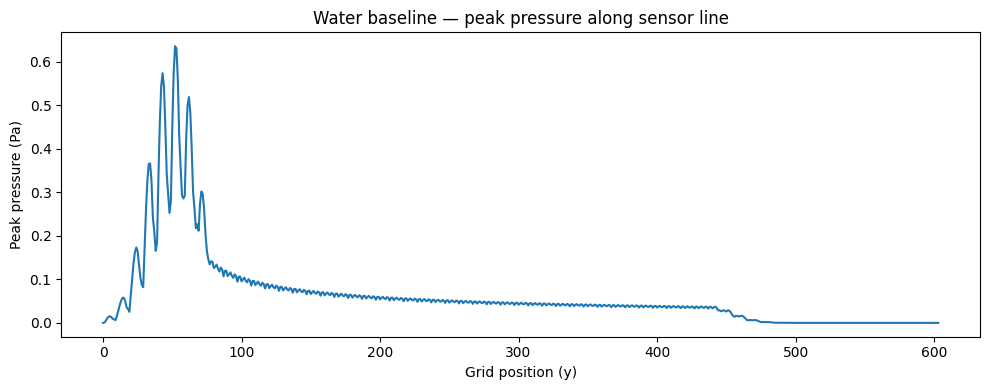

Max pressure: 0.64 Pa


In [2]:
# --- Parameters (Mueller et al. 500 kHz setup) ---
freq = 500e3          # 500 kHz
c0 = 1482.0           # speed of sound in water (m/s)
rho0 = 1000.0         # density of water (kg/m^3)

# --- Grid setup ---
wavelength = c0 / freq          # ~3 mm
dx = wavelength / 6             # 6 points per wavelength
Nx = 128
Ny = 128

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)

# --- Medium (pure water) ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source ---
source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[Nx // 2, 10] = 1
source.p = tone_burst(1/kgrid.dt, freq, 5)

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.zeros((Nx, Ny))
sensor.mask[Nx // 2, :] = 1

# --- Run ---
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')

# --- Plot ---
plt.figure(figsize=(10, 4))
p_max = np.max(np.abs(sensor_data['p']), axis=0)
plt.plot(p_max)
plt.xlabel('Grid position (y)')
plt.ylabel('Peak pressure (Pa)')
plt.title('Water baseline — peak pressure along sensor line')
plt.tight_layout()
plt.savefig('01_water_baseline.png')
plt.show()
print(f"Max pressure: {np.max(p_max):.2f} Pa")

### 02_focused_transducer

Grid size: 256 x 256, dt=1.00e-07s, Nt=1207
Number of source elements: 60
Burst length: 101 samples
Running simulation...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 846.24step/s]


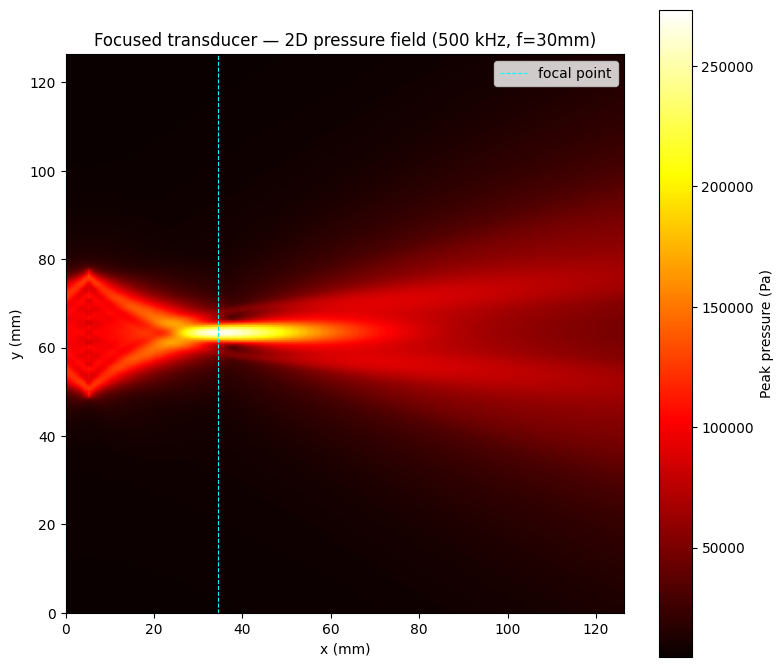

Max pressure: 273436.5 Pa
Done! Saved to 02_focused_transducer.png


In [3]:
# --- Parameters ---
freq  = 500e3
c0    = 1482.0
rho0  = 1000.0

# --- Grid ---
wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

# --- Medium ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Transducer geometry ---
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources = len(source_y_indices)

print(f"Grid size: {Nx} x {Ny}, dt={kgrid.dt:.2e}s, Nt={n_time}")
print(f"Number of source elements: {n_sources}")

# --- Build base tone burst ---
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

# Make sure n_time is long enough for burst + max delay
focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

# Compute delays
delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0

# Normalize so max delay fires first (converging focus)
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

# Ensure time array is long enough
n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    print(f"Extended n_time to {n_time}")

# --- Build source signals ---
source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

# Rebuild kgrid time with correct n_time
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run ---
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')

# --- Plot ---
p_max = sensor_data['p_max'].reshape(Nx, Ny)

plt.figure(figsize=(8, 7))
plt.imshow(p_max.T, aspect='equal',
           extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
           origin='lower', cmap='hot')
plt.colorbar(label='Peak pressure (Pa)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Focused transducer — 2D pressure field (500 kHz, f=30mm)')
plt.axvline(x=(transducer_x + int(focal_length/dx)) * dx * 1e3,
            color='cyan', linestyle='--', linewidth=0.8, label='focal point')
plt.legend()
plt.tight_layout()
plt.savefig('02_focused_transducer.png', dpi=150)
plt.show()
print(f"Max pressure: {np.max(p_max):.1f} Pa")
print("Done! Saved to 02_focused_transducer.png")

### 03_validate

Running simulation...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 890.96step/s]



=== VALIDATION ===

[1] Focal position
    Expected x: 34.6 mm
    Actual peak x: 34.6 mm
    Offset: 0.0 mm

[2] Beamwidth (FWHM)
    Simulated FWHM: 3.5 mm
    Mueller et al.: ~4-6 mm
    Match: YES

[3] Peak pressure at focus
    Simulated: 273 kPa
    Input source: 100 kPa
    Gain from focusing: 2.7x
    Mueller et al. (scaled to 1030 kPa): would need 3.8x more input


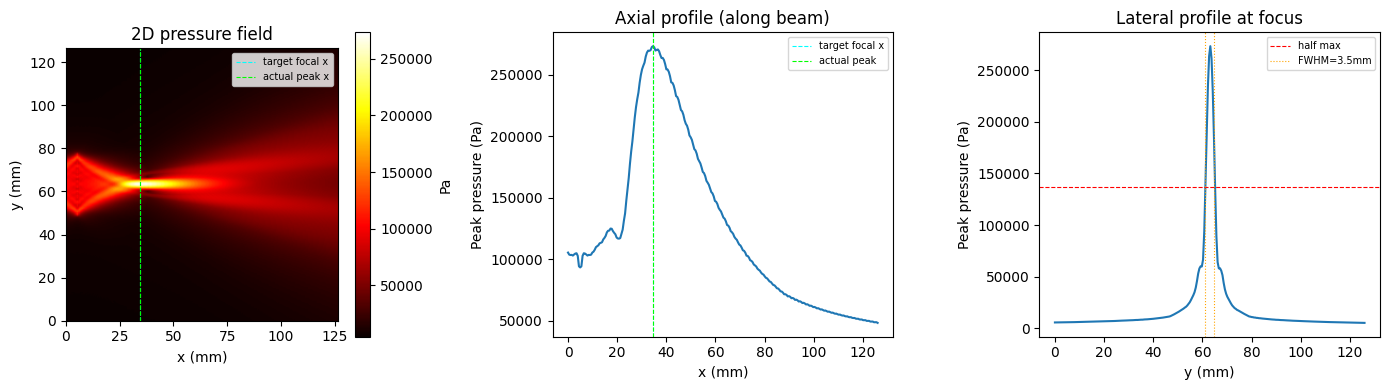


Saved to 03_validate.png


In [4]:
# --- Same parameters as 02 ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source (identical to 02) ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)

# --- Validation ---
print("\n=== VALIDATION ===")

# 1. Where is the actual peak?
peak_idx = np.unravel_index(np.argmax(p_max), p_max.shape)
peak_x_mm = peak_idx[0] * dx * 1e3
peak_y_mm = peak_idx[1] * dx * 1e3
expected_x_mm = (transducer_x + int(focal_length / dx)) * dx * 1e3
print(f"\n[1] Focal position")
print(f"    Expected x: {expected_x_mm:.1f} mm")
print(f"    Actual peak x: {peak_x_mm:.1f} mm")
print(f"    Offset: {abs(peak_x_mm - expected_x_mm):.1f} mm")

# 2. Beamwidth (FWHM) at focal plane
focal_profile = p_max[peak_idx[0], :]   # lateral slice at peak x
half_max = np.max(focal_profile) / 2
above_half = np.where(focal_profile >= half_max)[0]
if len(above_half) > 1:
    fwhm_mm = (above_half[-1] - above_half[0]) * dx * 1e3
else:
    fwhm_mm = 0
print(f"\n[2] Beamwidth (FWHM)")
print(f"    Simulated FWHM: {fwhm_mm:.1f} mm")
print(f"    Mueller et al.: ~4-6 mm")
print(f"    Match: {'YES' if 2 < fwhm_mm < 8 else 'CHECK'}")

# 3. Peak pressure
peak_pa  = np.max(p_max)
peak_kpa = peak_pa / 1e3
print(f"\n[3] Peak pressure at focus")
print(f"    Simulated: {peak_kpa:.0f} kPa")
print(f"    Input source: 100 kPa")
print(f"    Gain from focusing: {peak_kpa/100:.1f}x")
print(f"    Mueller et al. (scaled to 1030 kPa): would need {1030/peak_kpa:.1f}x more input")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: 2D field
ax = axes[0]
im = ax.imshow(p_max.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot')
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak x')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('2D pressure field')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

# Plot 2: Axial profile (along beam axis, through center)
ax = axes[1]
axial = p_max[:, center_y]
x_mm  = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, axial)
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile (along beam)')
ax.legend(fontsize=7)

# Plot 3: Lateral profile (FWHM)
ax = axes[2]
y_mm = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, focal_profile)
ax.axhline(y=half_max, color='red', linestyle='--', lw=0.8, label=f'half max')
ax.axvline(x=above_half[0]*dx*1e3,  color='orange', linestyle=':', lw=0.8)
ax.axvline(x=above_half[-1]*dx*1e3, color='orange', linestyle=':', lw=0.8, label=f'FWHM={fwhm_mm:.1f}mm')
ax.set_xlabel('y (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Lateral profile at focus')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('03_validate.png', dpi=150)
plt.show()
print("\nSaved to 03_validate.png")

### 04_skull_layer
Flat, infite length skull layer

dt=5.11e-08s, Nt=1207
Skull: x=24.7mm to 27.7mm
Burst length: 196 samples
Running with skull...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 826.38step/s]


Skull sim OK — max pressure: 746.8 kPa
Running water baseline...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 876.72step/s]


Water sim OK — max pressure: 274.4 kPa

=== SKULL VALIDATION ===
Peak pressure (water, post-skull):      274.4 kPa
Peak pressure (with skull, post-skull): 189.5 kPa
Transmission:               69.0%
Pressure loss:              31.0%
Mueller et al. expected:    ~65% transmission (35% loss)

Theoretical transmission (impedance only): 66.8%


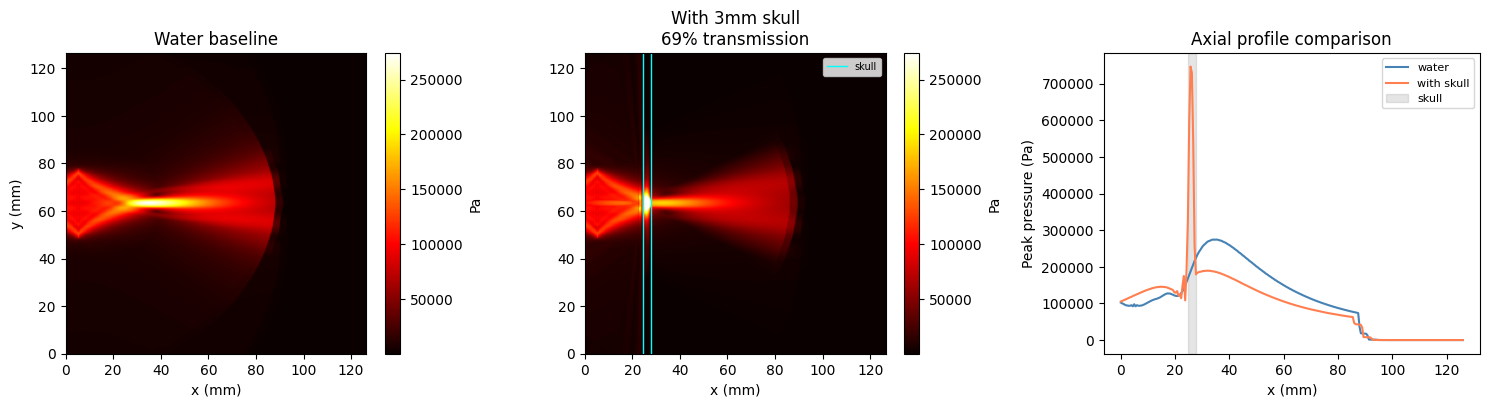

Saved to 04_skull_layer.png


In [5]:
# --- Parameters ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6

Nx, Ny = 256, 256

# --- Skull properties (Mueller et al.) ---
c_skull   = 2900.0
rho_skull = 1900.0

# Build grid using skull speed for stable dt
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)
n_time = kgrid.Nt
print(f"dt={kgrid.dt:.2e}s, Nt={n_time}")

# --- Skull geometry ---
skull_thickness_mm = 3.0
skull_start_x = transducer_x + int(20e-3 / dx)
skull_end_x   = skull_start_x + int(skull_thickness_mm * 1e-3 / dx)
print(f"Skull: x={skull_start_x*dx*1e3:.1f}mm to {skull_end_x*dx*1e3:.1f}mm")

# --- Heterogeneous medium (NO attenuation map — keep it simple first) ---
sound_speed_map = np.ones((Nx, Ny), dtype=float) * c0
density_map     = np.ones((Nx, Ny), dtype=float) * rho0
sound_speed_map[skull_start_x:skull_end_x, :] = c_skull
density_map[skull_start_x:skull_end_x, :]     = rho_skull

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

# --- Source ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), n_time)
    source_signals[i, d:end] = burst[:end-d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run with skull ---
print("Running with skull...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max_skull = sensor_data['p_max'].reshape(Nx, Ny)

# Check for NaN
if np.isnan(p_max_skull).any():
    print("WARNING: NaN detected in skull simulation")
else:
    print(f"Skull sim OK — max pressure: {np.nanmax(p_max_skull)/1e3:.1f} kPa")

# --- Run water baseline ---
medium_water = kWaveMedium(sound_speed=c0, density=rho0)
print("Running water baseline...")
sensor_data_water = kspaceFirstOrder(kgrid, medium_water, source, sensor, device='gpu', dtype='float32')
p_max_water = sensor_data_water['p_max'].reshape(Nx, Ny)
print(f"Water sim OK — max pressure: {np.max(p_max_water)/1e3:.1f} kPa")

# --- Results ---
# Only measure in post-skull region to avoid reflection artifacts
post_skull_water = p_max_water[skull_end_x:, :]
post_skull_skull = p_max_skull[skull_end_x:, :]

peak_water = np.max(post_skull_water)
peak_skull = np.max(post_skull_skull)
transmission = peak_skull / peak_water * 100

print(f"\n=== SKULL VALIDATION ===")
print(f"Peak pressure (water, post-skull):      {peak_water/1e3:.1f} kPa")
print(f"Peak pressure (with skull, post-skull): {peak_skull/1e3:.1f} kPa")
print(f"Transmission:               {transmission:.1f}%")
print(f"Pressure loss:              {100-transmission:.1f}%")
print(f"Mueller et al. expected:    ~65% transmission (35% loss)")

# --- Reflection coefficient check ---
Z_water = rho0 * c0
Z_skull = rho_skull * c_skull
R = ((Z_skull - Z_water) / (Z_skull + Z_water))**2
T_theoretical = 1 - R
print(f"\nTheoretical transmission (impedance only): {T_theoretical*100:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = np.max(p_max_water)

ax = axes[0]
im = ax.imshow(p_max_water.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.set_title('Water baseline')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[1]
im = ax.imshow(p_max_skull.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.axvline(x=skull_start_x*dx*1e3, color='cyan', lw=1)
ax.axvline(x=skull_end_x*dx*1e3,   color='cyan', lw=1, label='skull')
ax.set_title(f'With 3mm skull\n{transmission:.0f}% transmission')
ax.set_xlabel('x (mm)')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[2]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max_water[:, center_y], label='water', color='steelblue')
ax.plot(x_mm, p_max_skull[:, center_y], label='with skull', color='coral')
ax.axvspan(skull_start_x*dx*1e3, skull_end_x*dx*1e3,
           alpha=0.2, color='gray', label='skull')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('04_skull_layer.png', dpi=150)
plt.show()
print("Saved to 04_skull_layer.png")

# Round Skull Setups

### 05_circular_skull_setup
Reusable geometry: water coupling outside → circular skull ring → brain interior. No sources placed here — add them in subsequent test cells.

> **Note:** The exterior is water (c=1482, ρ=1000), not air. In real TUS the transducer always sits in a water coupling bath against the skull — there is no bare air-skull interface. Using air causes a density ratio of ~1570:1 at the bone boundary which overflows k-Wave's pseudospectral FFT solver regardless of CFL setting.

dx = 0.296 mm  (10 PPW)
Brain radius : 40.0 mm  (135.0 px)
Skull outer  : 45.0 mm  (151.8 px)
Grid edge    : 75.9 mm from centre
Skull-to-edge margin: 30.9 mm

kgrid: dt=1.02e-08 s,  Nt=7241
Estimated sim time per run: 7241 steps  (~74.0 µs of acoustic time)


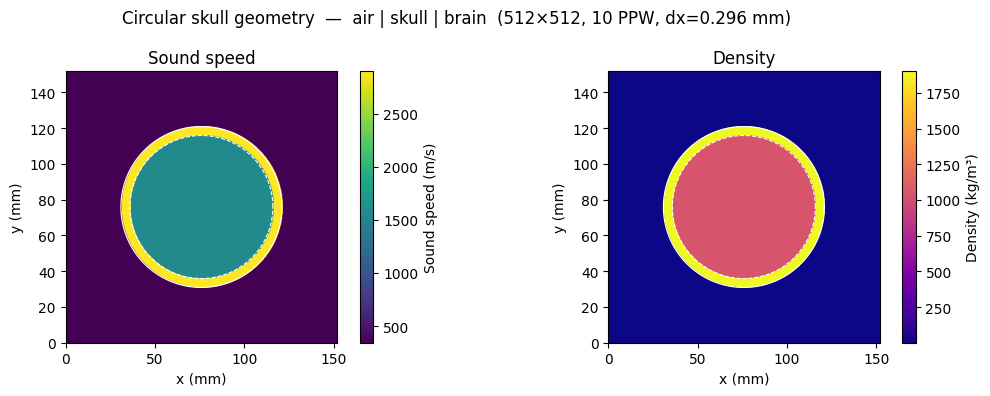

In [26]:
# ── Acoustic properties ──────────────────────────────────────────────────────
# Exterior = air: the device is mounted directly on the skull in-vivo (monkey).
# There is no water bath.  The transducer elements will be placed at the skull
# outer surface so the air medium never enters the acoustic propagation path.
c_air    = 343.0;    rho_air    = 1.21     # air (exterior / ambient)
c_skull  = 2900.0;   rho_skull  = 1900.0   # cortical bone (Mueller et al.)
c_brain  = 1560.0;   rho_brain  = 1040.0   # brain tissue

# ── Grid ─────────────────────────────────────────────────────────────────────
freq = 500e3
c0   = 1482.0          # water — used only for wavelength/dx sizing
wavelength = c0 / freq # ~3 mm

# Resolution: 10 points per wavelength (up from 6).
# Skull wall (~5 mm) spans ~17 grid points — enough to resolve the impedance
# ramp without numerical smearing.  Tradeoff: ~9× more compute than 6 PPW.
dx = wavelength / 10   # ~0.296 mm per grid point

Nx, Ny = 512, 512      # physical size ≈ 151 mm × 151 mm
cx, cy = Nx // 2, Ny // 2  # skull centre (grid indices)

# ── Skull geometry ────────────────────────────────────────────────────────────
brain_radius_mm    = 40.0   # inner radius of skull (brain surface)
skull_thickness_mm =  5.0   # skull wall thickness

skull_inner_px = brain_radius_mm                        * 1e-3 / dx
skull_outer_px = (brain_radius_mm + skull_thickness_mm) * 1e-3 / dx

print(f"dx = {dx*1e3:.3f} mm  ({wavelength/dx:.0f} PPW)")
print(f"Brain radius : {brain_radius_mm:.1f} mm  ({skull_inner_px:.1f} px)")
print(f"Skull outer  : {brain_radius_mm + skull_thickness_mm:.1f} mm  ({skull_outer_px:.1f} px)")
print(f"Grid edge    : {Nx//2 * dx*1e3:.1f} mm from centre")
print(f"Skull-to-edge margin: {(Nx//2 * dx - (brain_radius_mm + skull_thickness_mm)*1e-3)*1e3:.1f} mm")

# ── Build radial distance map ─────────────────────────────────────────────────
XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R = np.sqrt((XX - cx)**2 + (YY - cy)**2)

# ── Assign material properties ────────────────────────────────────────────────
sound_speed_map = np.full((Nx, Ny), c_air,   dtype=float)
density_map     = np.full((Nx, Ny), rho_air, dtype=float)

skull_mask = (R >= skull_inner_px) & (R < skull_outer_px)
brain_mask =  R <  skull_inner_px

sound_speed_map[skull_mask] = c_skull;  density_map[skull_mask] = rho_skull
sound_speed_map[brain_mask] = c_brain;  density_map[brain_mask] = rho_brain

# ── kWave grid and medium ─────────────────────────────────────────────────────
# CFL=0.1: skull/air density contrast ~1570:1 requires a tighter CFL for
# spectral-method stability.
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.1)

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

print(f"\nkgrid: dt={kgrid.dt:.2e} s,  Nt={kgrid.Nt}")
print(f"Estimated sim time per run: {kgrid.Nt} steps  "
      f"(~{kgrid.Nt * kgrid.dt * 1e6:.1f} µs of acoustic time)")

# ── Visualise geometry ────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
im = ax.imshow(sound_speed_map.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=ax, label='Sound speed (m/s)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Sound speed'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

ax = axes[1]
im = ax.imshow(density_map.T, origin='lower', extent=extent, cmap='plasma')
plt.colorbar(im, ax=ax, label='Density (kg/m³)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Density'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

plt.suptitle(f'Circular skull geometry  —  air | skull | brain  '
             f'({Nx}×{Ny}, {wavelength/dx:.0f} PPW, dx={dx*1e3:.3f} mm)')
plt.tight_layout()
plt.savefig('05_circular_skull_setup.png', dpi=150)
plt.show()

### 05.5 — Half-skull time reversal
**Hypothesis:** the ~4.4 mm near-shift in cell 09 is caused by far-wall reflections contaminating the forward recording. In a full circular skull, the point source at the target sends waves in all directions; right-going waves hit the far skull wall, bounce back, and arrive at the transducer with an extra delay. When time-reversed, those reflected components drive energy to the wrong depth.

**Fix:** remove the right-hemisphere skull ring for the *forward* sim only — the right-going wave exits freely. The clean element recordings are then time-reversed and replayed into the **full skull** to test focus quality in the real geometry.

Variables use the `_half` / `_h` suffix so they coexist with the full-skull variables from cell 05.

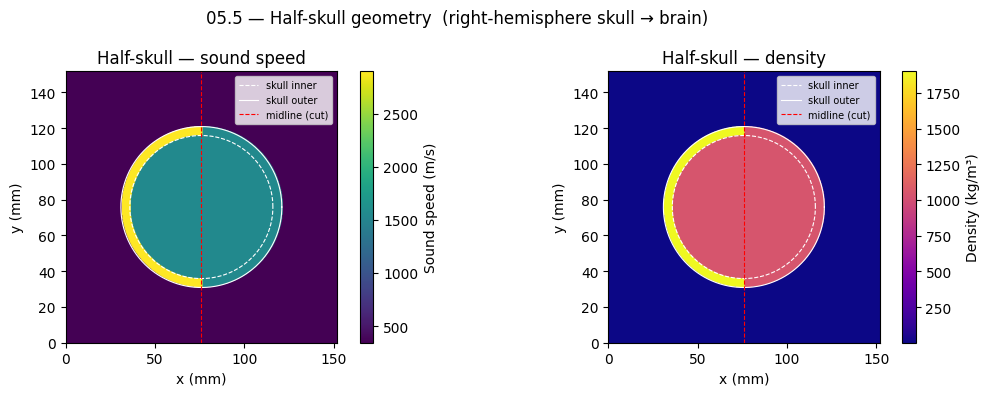

medium_half ready.
Transducer elements: 100  (aperture 30 mm on skull surface)

Step 1: forward sim on half skull…


k-Wave: 100%|██████████| 7241/7241 [00:07<00:00, 1008.05step/s]


  Recorded: (100, 7241)  (elements × time steps)


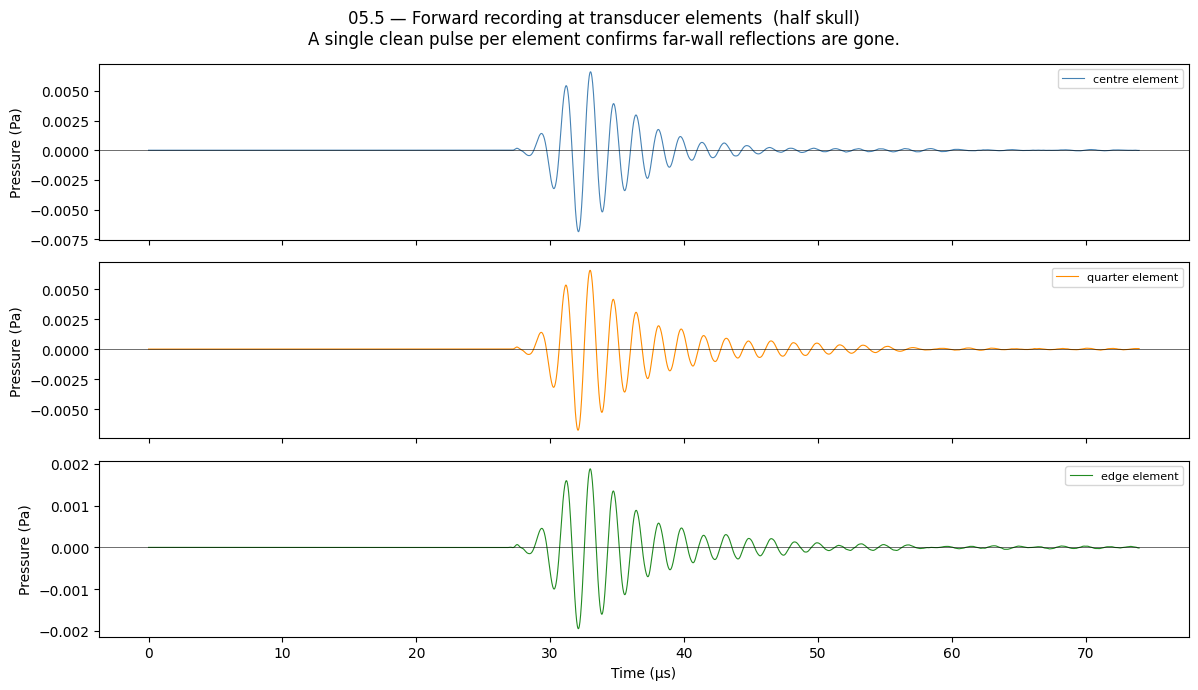

Step 2: backward sim on half skull…


k-Wave: 100%|██████████| 7241/7241 [00:12<00:00, 585.43step/s]


Done — global max: 0.0 kPa

=== FOCUS REPORT (half-skull TR, both sims on half skull) ===
Target  : (75.9, 75.9) mm
Actual  : (71.1, 75.9) mm
Error   : 4.7 mm
Peak P  : 0.0 kPa


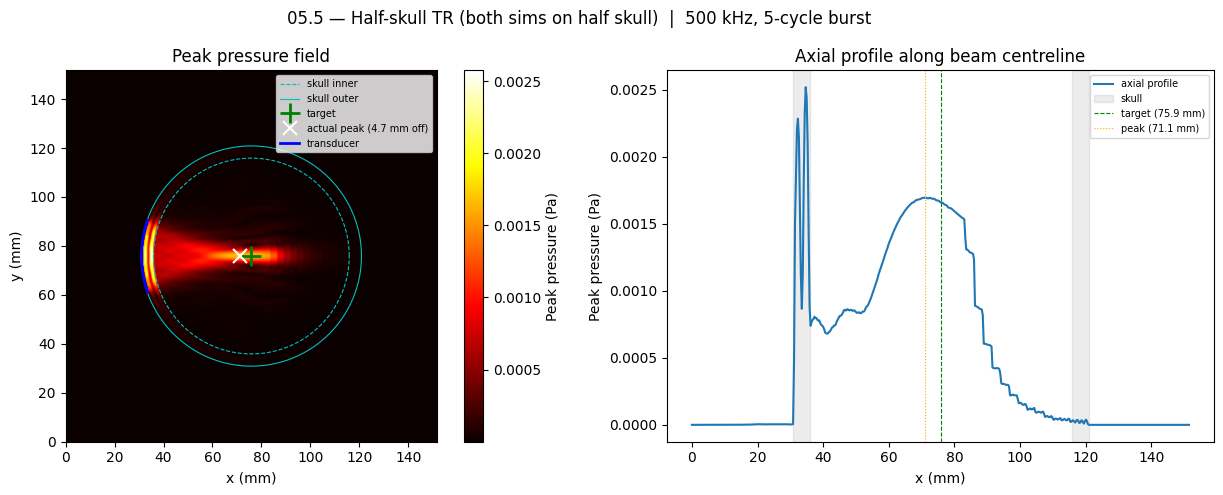

In [7]:
# Requires cell 05 to have been run first.
#
# Step 1: build the half-skull medium (right-hemisphere skull → brain).
# Step 2: run forward + backward entirely in the half skull to verify TR works
#         once far-wall reflections are removed.
# Diagnostic plots show element waveforms (clean vs echo) and the focus field.

# ── Half-skull geometry ───────────────────────────────────────────────────────
sound_speed_map_half = sound_speed_map.copy()
density_map_half     = density_map.copy()

right_skull_mask = skull_mask & (XX > cx)
sound_speed_map_half[right_skull_mask] = c_brain
density_map_half[right_skull_mask]     = rho_brain

medium_half = kWaveMedium(sound_speed=sound_speed_map_half, density=density_map_half)

# ── Geometry plot ─────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, arr, label, cmap in zip(
        axes,
        [sound_speed_map_half, density_map_half],
        ['Sound speed (m/s)', 'Density (kg/m³)'],
        ['viridis', 'plasma']):
    im = ax.imshow(arr.T, origin='lower', extent=extent, cmap=cmap)
    plt.colorbar(im, ax=ax, label=label)
    ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
            'w--', lw=0.8, label='skull inner')
    ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
            'w-',  lw=0.8, label='skull outer')
    ax.axvline(x=cx_mm_plot, color='red', lw=0.8, ls='--', label='midline (cut)')
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    ax.legend(fontsize=7)
axes[0].set_title('Half-skull — sound speed')
axes[1].set_title('Half-skull — density')
plt.suptitle('05.5 — Half-skull geometry  (right-hemisphere skull → brain)')
plt.tight_layout()
plt.savefig('05_5_half_skull_geometry.png', dpi=150)
plt.show()
print("medium_half ready.")

# ── Conforming array (same geometry as cells 07–09) ───────────────────────────
target_x, target_y = cx, cy
aperture_mm = 30.0
half_ap_px  = int((aperture_mm / 2) * 1e-3 / dx)

src_x_h, src_y_h = [], []
for y_i in np.arange(cy - half_ap_px, cy + half_ap_px):
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        src_x_h.append(cx - int(np.sqrt(skull_outer_px**2 - dy**2)))
        src_y_h.append(int(y_i))
src_x_h  = np.array(src_x_h)
src_y_h  = np.array(src_y_h)
n_elem_h = len(src_x_h)
print(f"Transducer elements: {n_elem_h}  (aperture {aperture_mm:.0f} mm on skull surface)")

elem_mask_h = np.zeros((Nx, Ny))
for xi, yi in zip(src_x_h, src_y_h):
    elem_mask_h[xi, yi] = 1

# ── Step 1: Forward sim on HALF skull ────────────────────────────────────────
src_fwd_h        = kSource()
src_fwd_h.p_mask = np.zeros((Nx, Ny))
src_fwd_h.p_mask[target_x, target_y] = 1
src_fwd_h.p     = tone_burst(1/kgrid.dt, freq, 5).flatten()

sen_fwd_h        = kSensor()
sen_fwd_h.mask   = elem_mask_h.copy()
sen_fwd_h.record = ['p']

print("\nStep 1: forward sim on half skull…")
data_fwd_h      = kspaceFirstOrder(kgrid, medium_half, src_fwd_h, sen_fwd_h, device='gpu', dtype='float32')
p_at_elements_h = data_fwd_h['p']   # shape: (n_elem, Nt)
print(f"  Recorded: {p_at_elements_h.shape}  (elements × time steps)")

# ── Diagnostic: element waveforms ────────────────────────────────────────────
# Show centre, quarter-point, and edge element to reveal whether
# far-wall reflections (late-arriving second pulse) are present.
t_us = np.arange(kgrid.Nt) * kgrid.dt * 1e6   # time axis in µs

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
sample_indices = [n_elem_h // 2, n_elem_h // 4, 0]   # centre, quarter, edge
labels         = ['centre element', 'quarter element', 'edge element']
colors         = ['steelblue', 'darkorange', 'forestgreen']

for ax, idx, lbl, col in zip(axes, sample_indices, labels, colors):
    ax.plot(t_us, p_at_elements_h[idx], color=col, lw=0.8, label=lbl)
    ax.set_ylabel('Pressure (Pa)')
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', lw=0.4)

axes[-1].set_xlabel('Time (µs)')
plt.suptitle('05.5 — Forward recording at transducer elements  (half skull)\n'
             'A single clean pulse per element confirms far-wall reflections are gone.')
plt.tight_layout()
plt.savefig('05_5_element_waveforms.png', dpi=150)
plt.show()

# ── Step 2: Backward sim on HALF skull ───────────────────────────────────────
p_reversed_h = p_at_elements_h[:, ::-1]

src_bwd_h        = kSource()
src_bwd_h.p_mask = elem_mask_h.copy()
src_bwd_h.p      = p_reversed_h

sen_bwd_h        = kSensor()
sen_bwd_h.mask   = np.ones((Nx, Ny))
sen_bwd_h.record = ['p_max']

print("Step 2: backward sim on half skull…")
data_bwd_h = kspaceFirstOrder(kgrid, medium_half, src_bwd_h, sen_bwd_h, device='gpu', dtype='float32')
p_max_h    = data_bwd_h['p_max'].reshape(Nx, Ny)
print(f"Done — global max: {np.max(p_max_h)/1e3:.1f} kPa")

# ── Focus report ──────────────────────────────────────────────────────────────
p_brain_h  = p_max_h.copy()
p_brain_h[~brain_mask] = 0
peak_idx_h = np.unravel_index(np.argmax(p_brain_h), (Nx, Ny))
peak_mm_h  = (peak_idx_h[0]*dx*1e3, peak_idx_h[1]*dx*1e3)
tgt_mm_h   = (target_x*dx*1e3, target_y*dx*1e3)
err_mm_h   = np.sqrt((peak_mm_h[0]-tgt_mm_h[0])**2 + (peak_mm_h[1]-tgt_mm_h[1])**2)

print(f"\n=== FOCUS REPORT (half-skull TR, both sims on half skull) ===")
print(f"Target  : ({tgt_mm_h[0]:.1f}, {tgt_mm_h[1]:.1f}) mm")
print(f"Actual  : ({peak_mm_h[0]:.1f}, {peak_mm_h[1]:.1f}) mm")
print(f"Error   : {err_mm_h:.1f} mm")
print(f"Peak P  : {np.max(p_brain_h)/1e3:.1f} kPa")

# ── Focus plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max_h.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm_h[0],  tgt_mm_h[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm_h[0], peak_mm_h[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm_h:.1f} mm off)')
ax.plot(src_x_h*dx*1e3, src_y_h*dx*1e3, 'b-', lw=2, label='transducer')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max_h[:, cy], label='axial profile')
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm_h[0],  color='green',  lw=0.8, ls='--', label=f'target ({tgt_mm_h[0]:.1f} mm)')
ax.axvline(x=peak_mm_h[0], color='orange', lw=0.8, ls=':',
           label=f'peak ({peak_mm_h[0]:.1f} mm)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('05.5 — Half-skull TR (both sims on half skull)  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('05_5_half_skull_tr.png', dpi=150)
plt.show()

### 06_centre_source
Single point source at the skull centre, 500 kHz 5-cycle burst — same signal as earlier tests. Uses the geometry from 05.

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:31<00:00, 231.71step/s]


Done — max pressure: 41.7 kPa


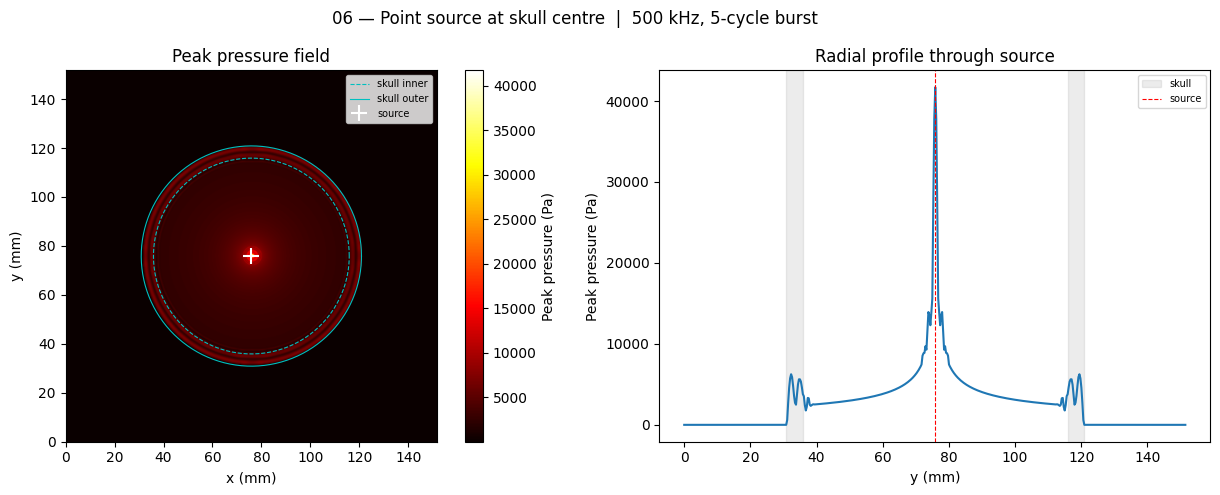

In [27]:
# Requires cell 05 to have been run first (kgrid, medium, cx, cy, dx, Nx, Ny,
# skull_inner_px, skull_outer_px, freq all come from there)

# ── Source: single point at skull centre ──────────────────────────────────────
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[cx, cy] = 1
source.p = burst * 1e5   # 100 kPa, matching earlier tests

# ── Sensor: full field, record peak pressure ──────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
cx_mm  = cx * dx * 1e3
cy_mm  = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3   # brain surface radius in mm
r_outer_mm = skull_outer_px * dx * 1e3   # outer skull radius in mm

theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D peak-pressure field
ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(cx_mm, cy_mm, 'w+', ms=12, mew=1.5, label='source')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

# Right: radial profile through centre
ax = axes[1]
radial = p_max[cx, :]                  # slice along y through source
y_mm   = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, radial)
ax.axvspan(cy_mm - r_outer_mm, cy_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cy_mm + r_inner_mm, cy_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=cy_mm, color='red', lw=0.8, linestyle='--', label='source')
ax.set_xlabel('y (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Radial profile through source')
ax.legend(fontsize=7)

plt.suptitle('06 — Point source at skull centre  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('06_centre_source.png', dpi=150)
plt.show()

### 07_external_focus
Phased linear array placed outside the skull, aimed at the brain centre. Time delays computed from straight-line distance to target (refraction ignored for this first pass — goal is to see where the wave actually lands and by how much it shifts).

Target       : (75.9, 75.9) mm
n_sources    : 100  (aperture 30 mm on skull surface)
Element x range: 105 – 113 px  (31.1 – 33.5 mm)
Max delay    : 0.10 µs  (9 steps)

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 645.88step/s]


Done — global max pressure: 25.5 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (70.8, 75.9) mm
Error   : 5.0 mm
Peak P  : 16.4 kPa  (in brain)


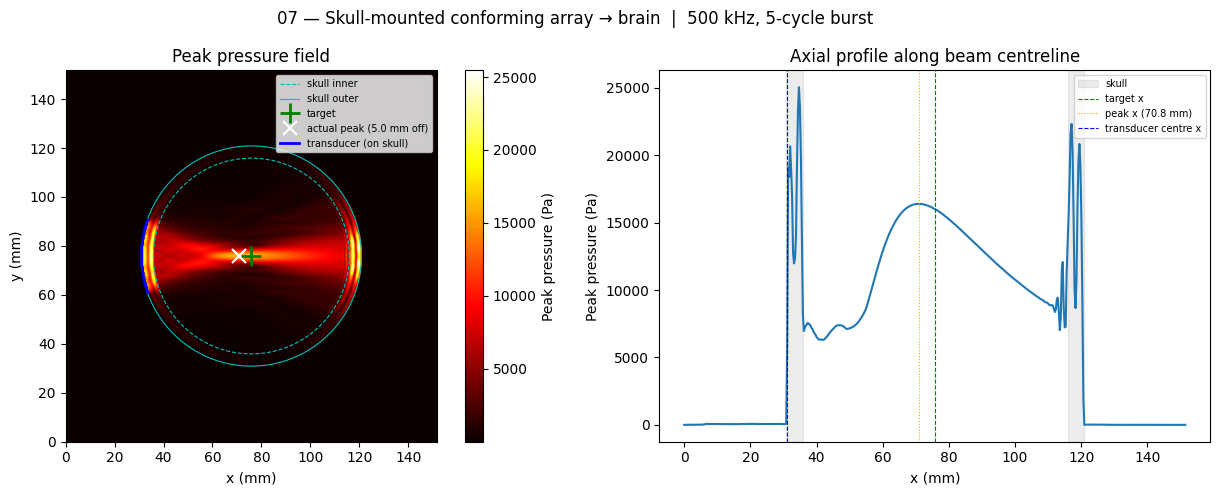

In [9]:
# Requires cell 05 to have been run first.
#
# Transducer model: conforming array mounted directly on the skull outer surface.
# Each element is placed at its corresponding point on the skull outer circle so
# there is no air gap and the source drives bone directly.  Delays are computed
# through skull + brain only (no air/water coupling segment).

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # aim at brain centre (change to steer)
target_y = cy

# ── Conforming array: elements placed on the skull outer surface ───────────────
# For each element at vertical position y_i, its x position on the left skull arc:
#   x_i = cx - floor( sqrt(skull_outer_px^2 - (y_i - cy)^2) )
# floor() puts the point just inside skull material.
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:          # within the skull circle's y-extent
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}  (aperture {aperture_mm:.0f} mm on skull surface)")
print(f"Element x range: {src_x.min()} – {src_x.max()} px  "
      f"({src_x.min()*dx*1e3:.1f} – {src_x.max()*dx*1e3:.1f} mm)")

# ── Multi-medium travel-time delays: skull → brain ────────────────────────────
# Source is at the skull outer surface; path = skull segment + brain segment.
# Find the skull/brain boundary by intersecting each ray with the inner circle.

def _ray_circle_t(ox, oy, ux, uy, R):
    """
    Parametric distance t (m) where unit-ray from (ox, oy) first enters a
    circle of radius R at the origin.  Returns (t_entry, t_exit) or (None, None).
    """
    b    = 2.0 * (ox * ux + oy * uy)
    c    = ox * ox + oy * oy - R * R
    disc = b * b - 4.0 * c
    if disc < 0.0:
        return None, None
    sq = np.sqrt(disc)
    return (-b - sq) / 2.0, (-b + sq) / 2.0

R_inner_m = skull_inner_px * dx   # brain surface radius (m)

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi, yi = src_x[i], src_y[i]
    vec_x  = (target_x - xi) * dx
    vec_y  = (target_y - yi) * dx
    dist_m = np.sqrt(vec_x**2 + vec_y**2)
    ux, uy = vec_x / dist_m, vec_y / dist_m

    # Ray origin relative to skull centre
    ox = (xi - cx) * dx
    oy = (yi - cy) * dx

    t_br_in, _ = _ray_circle_t(ox, oy, ux, uy, R_inner_m)

    if t_br_in is None or t_br_in < 0:
        travel_times[i] = dist_m / c_brain           # fallback
    else:
        travel_times[i] = (t_br_in          / c_skull +   # through skull
                           (dist_m - t_br_in) / c_brain)  # through brain

delays_s = travel_times.max() - travel_times         # centre element fires last
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm*np.cos(theta), cy_mm + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm*np.cos(theta), cy_mm + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
# Draw transducer arc on skull surface
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm - r_outer_mm, cx_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm + r_inner_mm, cx_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('07 — Skull-mounted conforming array → brain  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('07_external_focus.png', dpi=150)
plt.show()

### 08_fermat_focus
Same skull-mounted conforming array as cell 07, but delays computed via **Fermat's principle** rather than straight-line distances. For each element the crossing point on the skull-brain boundary is numerically optimised so that `d_skull/c_skull + d_brain/c_brain` is minimised — this automatically satisfies Snell's law and removes the ~5 mm near-shift caused by skull-brain refraction.

Target       : (75.9, 75.9) mm
n_sources    : 100
Max delay    : 0.10 µs  (9 steps)

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 614.98step/s]


Done — global max pressure: 25.5 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (70.8, 75.9) mm
Error   : 5.0 mm
Peak P  : 16.4 kPa  (in brain)


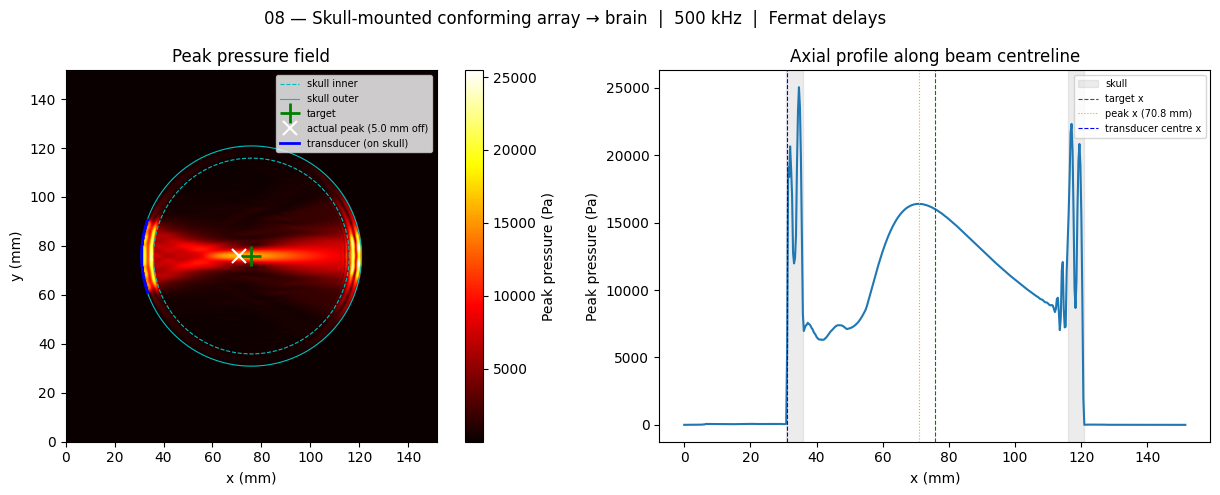

In [10]:
# Requires cell 05 to have been run first.
#
# Delays use Fermat's principle: for each element, the crossing point on the
# skull-brain boundary is optimised to minimise skull_path/c_skull + brain_path/c_brain.
# This satisfies Snell's law at the boundary and corrects the near-shift that
# straight-ray delays produce.

from scipy.optimize import minimize_scalar

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # brain centre — change to steer
target_y = cy

# ── Conforming array on skull outer surface ───────────────────────────────────
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}")

# ── Fermat-optimal delays ─────────────────────────────────────────────────────
cx_m      = cx * dx
cy_m      = cy * dx
R_inner_m = skull_inner_px * dx

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi_m = src_x[i] * dx
    yi_m = src_y[i] * dx
    tx_m = target_x * dx
    ty_m = target_y * dx

    phi_elem = np.arctan2(yi_m - cy_m, xi_m - cx_m)

    def time_fn(phi):
        Px = cx_m + R_inner_m * np.cos(phi)
        Py = cy_m + R_inner_m * np.sin(phi)
        return (np.sqrt((xi_m - Px)**2 + (yi_m - Py)**2) / c_skull +
                np.sqrt((tx_m - Px)**2 + (ty_m - Py)**2) / c_brain)

    res = minimize_scalar(time_fn,
                          bounds=(phi_elem - np.pi / 2, phi_elem + np.pi / 2),
                          method='bounded')
    travel_times[i] = res.fun

delays_s = travel_times.max() - travel_times
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('08 — Skull-mounted conforming array → brain  |  500 kHz  |  Fermat delays')
plt.tight_layout()
plt.savefig('08_fermat_focus.png', dpi=150)
plt.show()

### 09_time_reversal
Two-step time-reversal focus. **Step 1 (forward):** place a point source at the target, run the simulation, record the pressure time-series at every transducer element. **Step 2 (backward):** flip those recordings in time and replay them as source signals. The time-reversed signals carry exactly the phase correction needed to focus at the target — they account for refraction, impedance-mismatch reflections, and all other propagation effects automatically, without any analytical delay model.

Transducer elements: 100  (aperture 30 mm on skull surface)
Step 1: forward simulation (target → elements)…


k-Wave: 100%|██████████| 7241/7241 [00:06<00:00, 1080.68step/s]


  Recorded: (100, 7241)  (elements × time steps)
Step 2: backward simulation (time-reversed focus)…


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 618.09step/s]


Done — global max: 0.0 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (71.1, 75.9) mm
Error   : 4.7 mm
Peak P  : 0.0 kPa


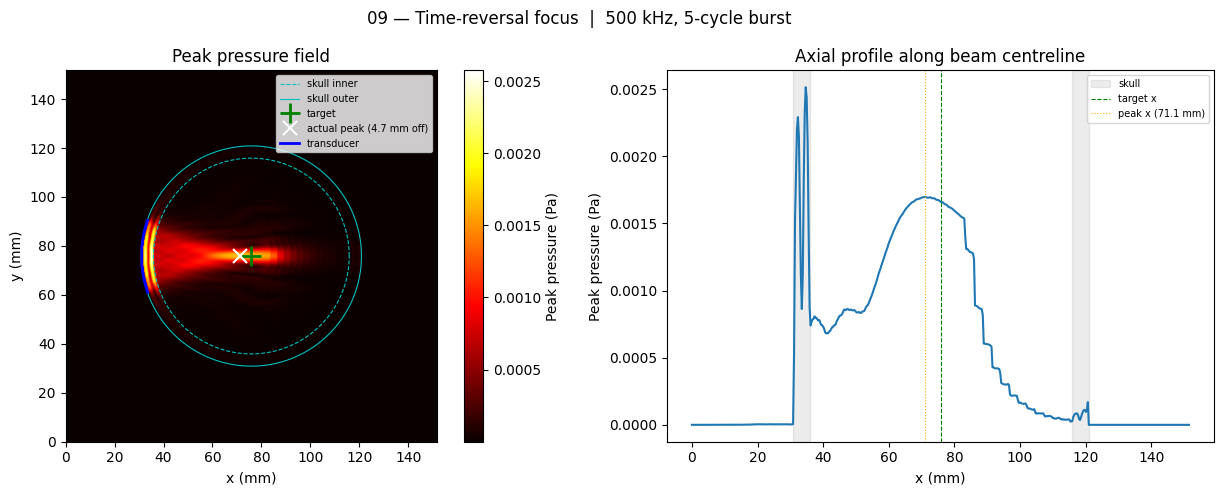

In [11]:
# Requires cell 05 to have been run first.
#
# Time-reversal focusing — two simulations:
#   1. Forward:  point source at target → record pressure at each transducer element
#   2. Backward: time-reversed recordings → focus pressure back at the target

# ── Target ────────────────────────────────────────────────────────────────────
target_x = cx
target_y = cy

# ── Conforming array (same geometry as cells 07/08) ───────────────────────────
aperture_mm = 30.0
half_ap_px  = int((aperture_mm / 2) * 1e-3 / dx)

src_x, src_y = [], []
for y_i in np.arange(cy - half_ap_px, cy + half_ap_px):
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        src_x.append(cx - int(np.sqrt(skull_outer_px**2 - dy**2)))
        src_y.append(int(y_i))
src_x = np.array(src_x)
src_y = np.array(src_y)
n_elem = len(src_x)
print(f"Transducer elements: {n_elem}  (aperture {aperture_mm:.0f} mm on skull surface)")

# ── Build element mask (used for both forward sensor and backward source) ──────
elem_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    elem_mask[xi, yi] = 1

# ── Step 1: Forward simulation — point source at target ───────────────────────
src_fwd       = kSource()
src_fwd.p_mask = np.zeros((Nx, Ny))
src_fwd.p_mask[target_x, target_y] = 1
src_fwd.p     = tone_burst(1/kgrid.dt, freq, 5).flatten()

sen_fwd        = kSensor()
sen_fwd.mask   = elem_mask.copy()
sen_fwd.record = ['p']          # full time-series at every element

print("Step 1: forward simulation (target → elements)…")
data_fwd = kspaceFirstOrder(kgrid, medium, src_fwd, sen_fwd, device='gpu', dtype='float32')
p_at_elements = data_fwd['p']   # shape: (n_elem, Nt)
print(f"  Recorded: {p_at_elements.shape}  (elements × time steps)")

# ── Step 2: Backward simulation — time-reversed signals ───────────────────────
p_reversed = p_at_elements[:, ::-1]   # flip each element's signal in time

src_bwd        = kSource()
src_bwd.p_mask = elem_mask.copy()
src_bwd.p      = p_reversed

sen_bwd        = kSensor()
sen_bwd.mask   = np.ones((Nx, Ny))
sen_bwd.record = ['p_max']

print("Step 2: backward simulation (time-reversed focus)…")
data_bwd = kspaceFirstOrder(kgrid, medium, src_bwd, sen_bwd, device='gpu', dtype='float32')
p_max = data_bwd['p_max'].reshape(Nx, Ny)
print(f"Done — global max: {np.max(p_max)/1e3:.1f} kPa")

# ── Focus report ──────────────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x*dx*1e3, src_y*dx*1e3, 'b-', lw=2, label='transducer')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('09 — Time-reversal focus  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('09_time_reversal.png', dpi=150)
plt.show()

### 10_flat_transducer_tr
Two changes from cells 07–09:
1. **Water exterior** instead of air — matches gel coupling used in vivo. Removes the 13,000:1 air/skull impedance ratio that forced CFL=0.1 and created numerical stiffness; CFL=0.3 is now stable (3× fewer time steps).
2. **Flat transducer** at a fixed x, 5 mm standoff from the skull — matches the actual experimental hardware.

Time-reversal is used for focusing, as in cell 09. If the near-skull focus shift persists after both changes, it isolates skull geometry (thickness, curvature) as the root cause rather than source/medium modelling artefacts.

In [ ]:
# Self-contained -- does not require cell 05 to have been run first.
#
# Key differences from cell 09:
#   - Exterior medium = water (gel coupling), not air -> CFL=0.3, 3x fewer steps
#   - Flat transducer: finite-aperture vertical line, 5 mm standoff from skull
#   - Animations saved for both forward and backward sims (sparse-grid recording)

from matplotlib.animation import FuncAnimation, PillowWriter

# -- Acoustic properties
c_water  = 1482.0;  rho_water  = 1000.0
c_skull  = 2900.0;  rho_skull  = 1900.0
c_brain  = 1560.0;  rho_brain  = 1040.0

# -- Grid
freq  = 500e3
dx    = (c_water / freq) / 10        # ~0.296 mm (10 PPW)
Nx, Ny    = 512, 512
cx10, cy10 = Nx // 2, Ny // 2

brain_radius_mm    = 40.0
skull_thickness_mm =  5.0
skull_inner_px10   = brain_radius_mm                        * 1e-3 / dx
skull_outer_px10   = (brain_radius_mm + skull_thickness_mm) * 1e-3 / dx

XX10, YY10 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R10 = np.sqrt((XX10 - cx10)**2 + (YY10 - cy10)**2)
skull_mask10 = (R10 >= skull_inner_px10) & (R10 < skull_outer_px10)
brain_mask10 =  R10 <  skull_inner_px10

sound_speed_map10 = np.full((Nx, Ny), c_water,  dtype=float)
density_map10     = np.full((Nx, Ny), rho_water, dtype=float)
sound_speed_map10[skull_mask10] = c_skull;  density_map10[skull_mask10] = rho_skull
sound_speed_map10[brain_mask10] = c_brain;  density_map10[brain_mask10] = rho_brain

kgrid10 = kWaveGrid([Nx, Ny], [dx, dx])
kgrid10.makeTime(c_skull, cfl=0.3)
medium10 = kWaveMedium(sound_speed=sound_speed_map10, density=density_map10)
print(f"dx={dx*1e3:.3f} mm  Nt={kgrid10.Nt}  dt={kgrid10.dt:.2e} s")

# -- Flat transducer (finite aperture)
standoff_mm    = 5.0
transducer_x10 = cx10 - int(skull_outer_px10) - int(standoff_mm * 1e-3 / dx)
aperture_mm    = 30.0
half_ap_px     = int((aperture_mm / 2) * 1e-3 / dx)
src_y10        = np.arange(cy10 - half_ap_px, cy10 + half_ap_px)
src_x10        = np.full(len(src_y10), transducer_x10, dtype=int)
n_elem10       = len(src_y10)

tx_mm10     = transducer_x10  * dx * 1e3
ty_min_mm10 = src_y10.min()   * dx * 1e3
ty_max_mm10 = src_y10.max()   * dx * 1e3
tgt_mm10    = (cx10 * dx * 1e3, cy10 * dx * 1e3)

print(f"Flat transducer: x={tx_mm10:.1f} mm, y={ty_min_mm10:.1f}-{ty_max_mm10:.1f} mm  ({aperture_mm:.0f} mm, {n_elem10} elements)")
print(f"Target (brain centre): ({tgt_mm10[0]:.1f}, {tgt_mm10[1]:.1f}) mm")

elem_mask10 = np.zeros((Nx, Ny))
for xi, yi in zip(src_x10, src_y10):
    elem_mask10[int(xi), int(yi)] = 1

# -- Animation sensor: every 4th grid point -> 128x128, ~158 MB per sim
STRIDE    = 4
anim_Nx   = Nx // STRIDE
anim_Ny   = Ny // STRIDE
anim_mask = np.zeros((Nx, Ny), dtype=float)
anim_mask[::STRIDE, ::STRIDE] = 1
anim_dt      = max(1, kgrid10.Nt // 150)
t_frame_us   = np.arange(0, kgrid10.Nt, anim_dt) * kgrid10.dt * 1e6

# -- Shared forward source
burst10 = tone_burst(1 / kgrid10.dt, freq, 5).flatten()
src_fwd10        = kSource()
src_fwd10.p_mask = np.zeros((Nx, Ny))
src_fwd10.p_mask[cx10, cy10] = 1
src_fwd10.p      = burst10

# =============================================================================
# STEP 1  Forward science sim (brain centre -> element recordings for TR)
# =============================================================================
sen_fwd10        = kSensor()
sen_fwd10.mask   = elem_mask10.copy()
sen_fwd10.record = ['p']

print("\nStep 1 - forward science...")
data_fwd10  = kspaceFirstOrder(kgrid10, medium10, src_fwd10, sen_fwd10,
                                device='gpu', dtype='float32')
p_at_elem10 = data_fwd10['p']       # (n_elem, Nt) - used for TR
print(f"  element recordings: {p_at_elem10.shape}")

# =============================================================================
# STEP 1-anim  Forward animation sim (same source, sparse sensor)
# =============================================================================
sen_fwd_anim        = kSensor()
sen_fwd_anim.mask   = anim_mask.copy()
sen_fwd_anim.record = ['p']

print("Step 1-anim - forward animation...")
data_fwd_anim = kspaceFirstOrder(kgrid10, medium10, src_fwd10, sen_fwd_anim,
                                  device='gpu', dtype='float32', quiet=True)
# (16384, Nt) -> subsample time -> reshape to (128, 128, n_frames)
p_fwd_frames = (data_fwd_anim['p'][:, ::anim_dt]
                .reshape(anim_Nx, anim_Ny, len(t_frame_us)))
print(f"  forward animation: {p_fwd_frames.shape}")

# Waveform diagnostic
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_us_all = np.arange(kgrid10.Nt) * kgrid10.dt * 1e6
for ax, idx, lbl, col in zip(axes, [n_elem10 // 2, 0],
                              ['centre element', 'edge element'],
                              ['steelblue', 'darkorange']):
    ax.plot(t_us_all, p_at_elem10[idx], color=col, lw=0.7, label=lbl)
    ax.set_ylabel('Pressure (Pa)')
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', lw=0.4)
axes[-1].set_xlabel('Time (us)')
plt.suptitle('10 - Forward recording: flat transducer elements')
plt.tight_layout()
plt.savefig('10_flat_tr_waveforms.png', dpi=150)
plt.show()

# =============================================================================
# STEP 2  Backward science sim (TR focus -> p_max field)
# =============================================================================
p_rev10 = p_at_elem10[:, ::-1]

src_bwd10        = kSource()
src_bwd10.p_mask = elem_mask10.copy()
src_bwd10.p      = p_rev10

sen_bwd10        = kSensor()
sen_bwd10.mask   = np.ones((Nx, Ny))
sen_bwd10.record = ['p_max']

print("Step 2 - backward science...")
data_bwd10 = kspaceFirstOrder(kgrid10, medium10, src_bwd10, sen_bwd10,
                               device='gpu', dtype='float32')
p_max10    = data_bwd10['p_max'].reshape(Nx, Ny)
print(f"  global max: {np.max(p_max10):.4e} Pa")

# =============================================================================
# STEP 2-anim  Backward animation sim (same TR source, sparse sensor)
# =============================================================================
sen_bwd_anim        = kSensor()
sen_bwd_anim.mask   = anim_mask.copy()
sen_bwd_anim.record = ['p']

print("Step 2-anim - backward animation...")
data_bwd_anim = kspaceFirstOrder(kgrid10, medium10, src_bwd10, sen_bwd_anim,
                                  device='gpu', dtype='float32', quiet=True)
p_bwd_frames = (data_bwd_anim['p'][:, ::anim_dt]
                .reshape(anim_Nx, anim_Ny, len(t_frame_us)))
print(f"  backward animation: {p_bwd_frames.shape}")

# -- Focus report
p_brain10  = p_max10.copy()
p_brain10[~brain_mask10] = 0
peak_idx10 = np.unravel_index(np.argmax(p_brain10), (Nx, Ny))
peak_mm10  = (peak_idx10[0]*dx*1e3, peak_idx10[1]*dx*1e3)
err_mm10   = np.sqrt((peak_mm10[0]-tgt_mm10[0])**2 + (peak_mm10[1]-tgt_mm10[1])**2)
axial_err  = peak_mm10[0] - tgt_mm10[0]
peak_P     = np.max(p_brain10)

print(f"\n=== FOCUS REPORT - cell 10 ===")
print(f"Target  : ({tgt_mm10[0]:.1f}, {tgt_mm10[1]:.1f}) mm")
print(f"Actual  : ({peak_mm10[0]:.1f}, {peak_mm10[1]:.1f}) mm")
print(f"Axial error  : {axial_err:+.1f} mm  (negative = closer to skull than target)")
print(f"Total error  : {err_mm10:.1f} mm")
print(f"Peak P (brain): {peak_P:.4e} Pa  (TR amplitude; focus position is the metric)")
if abs(axial_err) < 2.0:
    print("-> Axial error ~ 0: water + flat transducer resolves the shift")
else:
    print("-> Axial error persists: skull curvature is acting as a converging lens")

# -- Static focus plot
extent10     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta10      = np.linspace(0, 2*np.pi, 360)
cx_mm10      = cx10 * dx * 1e3
cy_mm10      = cy10 * dx * 1e3
r_inner_mm10 = skull_inner_px10 * dx * 1e3
r_outer_mm10 = skull_outer_px10 * dx * 1e3

def _overlay(ax):
    ax.plot(cx_mm10 + r_inner_mm10*np.cos(theta10), cy_mm10 + r_inner_mm10*np.sin(theta10),
            'c--', lw=0.8, label='skull inner')
    ax.plot(cx_mm10 + r_outer_mm10*np.cos(theta10), cy_mm10 + r_outer_mm10*np.sin(theta10),
            'c-',  lw=0.8, label='skull outer')
    # Finite aperture transducer shown as a line segment (not axvline)
    ax.plot([tx_mm10, tx_mm10], [ty_min_mm10, ty_max_mm10],
            color='dodgerblue', lw=3, solid_capstyle='butt',
            label=f'transducer ({aperture_mm:.0f} mm)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max10.T, origin='lower', extent=extent10, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
_overlay(ax)
ax.plot(tgt_mm10[0],  tgt_mm10[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm10[0], peak_mm10[1], 'wx',  ms=10, mew=1.5,
        label=f'peak ({err_mm10:.1f} mm off)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm10 = np.arange(Nx) * dx * 1e3
ax.plot(x_mm10, p_max10[:, cy10], label='axial profile (y=centre)')
ax.axvspan(cx_mm10 - r_outer_mm10, cx_mm10 - r_inner_mm10, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm10 + r_inner_mm10, cx_mm10 + r_outer_mm10, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm10[0],  color='green',  lw=0.8, ls='--', label='target x')
ax.axvline(x=peak_mm10[0], color='orange', lw=0.8, ls=':',
           label=f'peak x ({peak_mm10[0]:.1f} mm, err={axial_err:+.1f} mm)')
ax.axvline(x=tx_mm10, color='dodgerblue', lw=0.8, ls='--', label='transducer x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('10 - Flat transducer + water exterior | TR focusing | 500 kHz')
plt.tight_layout()
plt.savefig('10_flat_transducer_tr.png', dpi=150)
plt.show()

# -- Animations
def save_wave_animation(frames, label, filename):
    """
    frames: (anim_Nx, anim_Ny, n_frames)
    Red = positive pressure, Blue = negative (RdBu_r colormap).
    Saved as GIF at 25 fps.
    """
    n_t  = frames.shape[2]
    vmax = np.percentile(np.abs(frames), 99.5)
    if vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(5.5, 5.5), tight_layout=True)
    im = ax.imshow(frames[:, :, 0].T, origin='lower', extent=extent10,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    plt.colorbar(im, ax=ax, label='Pressure (Pa)', shrink=0.85)
    # Skull rings
    ax.plot(cx_mm10 + r_inner_mm10*np.cos(theta10), cy_mm10 + r_inner_mm10*np.sin(theta10),
            'k--', lw=0.7, alpha=0.5)
    ax.plot(cx_mm10 + r_outer_mm10*np.cos(theta10), cy_mm10 + r_outer_mm10*np.sin(theta10),
            'k-',  lw=0.7, alpha=0.5)
    # Finite-aperture transducer
    ax.plot([tx_mm10, tx_mm10], [ty_min_mm10, ty_max_mm10],
            color='dodgerblue', lw=3, solid_capstyle='butt')
    ax.plot(tgt_mm10[0], tgt_mm10[1], 'g+', ms=10, mew=2)
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    title_obj = ax.set_title(f'{label}  t = {t_frame_us[0]:.1f} us')

    def update(fi):
        im.set_data(frames[:, :, fi].T)
        title_obj.set_text(f'{label}  t = {t_frame_us[fi]:.1f} us')
        return [im, title_obj]

    anim = FuncAnimation(fig, update, frames=n_t, interval=40, blit=True)
    print(f"Saving {filename} ({n_t} frames @ 25 fps)...")
    anim.save(filename, writer=PillowWriter(fps=25), dpi=100)
    plt.close()
    print(f"  -> saved {filename}")

save_wave_animation(p_fwd_frames, 'Forward (brain -> transducer)', '10_forward.gif')
save_wave_animation(p_bwd_frames, 'Backward / TR focus',           '10_backward.gif')


### 11_skull_curvature_sweep
The -8 mm axial focus shift seen in cell 10 persists after switching to water exterior and a flat transducer, so the root cause is the skull geometry.

**Hypothesis:** the circular inner skull surface acts as a converging acoustic lens. Waves from outside slow down when entering brain tissue (c₂ < c₁), and a concave surface bends them toward the axis — pulling the TR focus closer to the skull.

**Test:** sweep (1) brain radius (curvature) and (2) skull thickness, measure axial shift each time.
- If shift ∝ 1/radius → confirmed geometric lens effect
- If shift ∝ thickness → path-length / impedance effect dominates

Each data point = 2 GPU sims (~3 s each). Total ~20 sims ≈ 60 s.

Nt=2414  dt=3.07e-08 s  (same for all sweep configs)

=== SWEEP 1: brain radius  (skull thickness = 5 mm) ===
  r = 25 mm  ->  axial shift = +0.0 mm
  r = 30 mm  ->  axial shift = +0.0 mm
  r = 35 mm  ->  axial shift = -5.9 mm
  r = 40 mm  ->  axial shift = -8.0 mm
  r = 45 mm  ->  axial shift = -9.8 mm
  r = 50 mm  ->  axial shift = -11.3 mm

=== SWEEP 2: skull thickness  (brain radius = 40 mm) ===
  t = 2 mm  ->  axial shift = -6.8 mm
  t = 4 mm  ->  axial shift = -8.0 mm
  t = 6 mm  ->  axial shift = -8.9 mm
  t = 8 mm  ->  axial shift = -8.3 mm

=== SUMMARY ===
Radius sweep  : min shift = -11.3 mm  (r=50 mm)
               max shift = +0.0 mm  (r=25 mm)
Thickness sweep: range -8.9 to -6.8 mm
Dominant factor: brain radius (curvature)


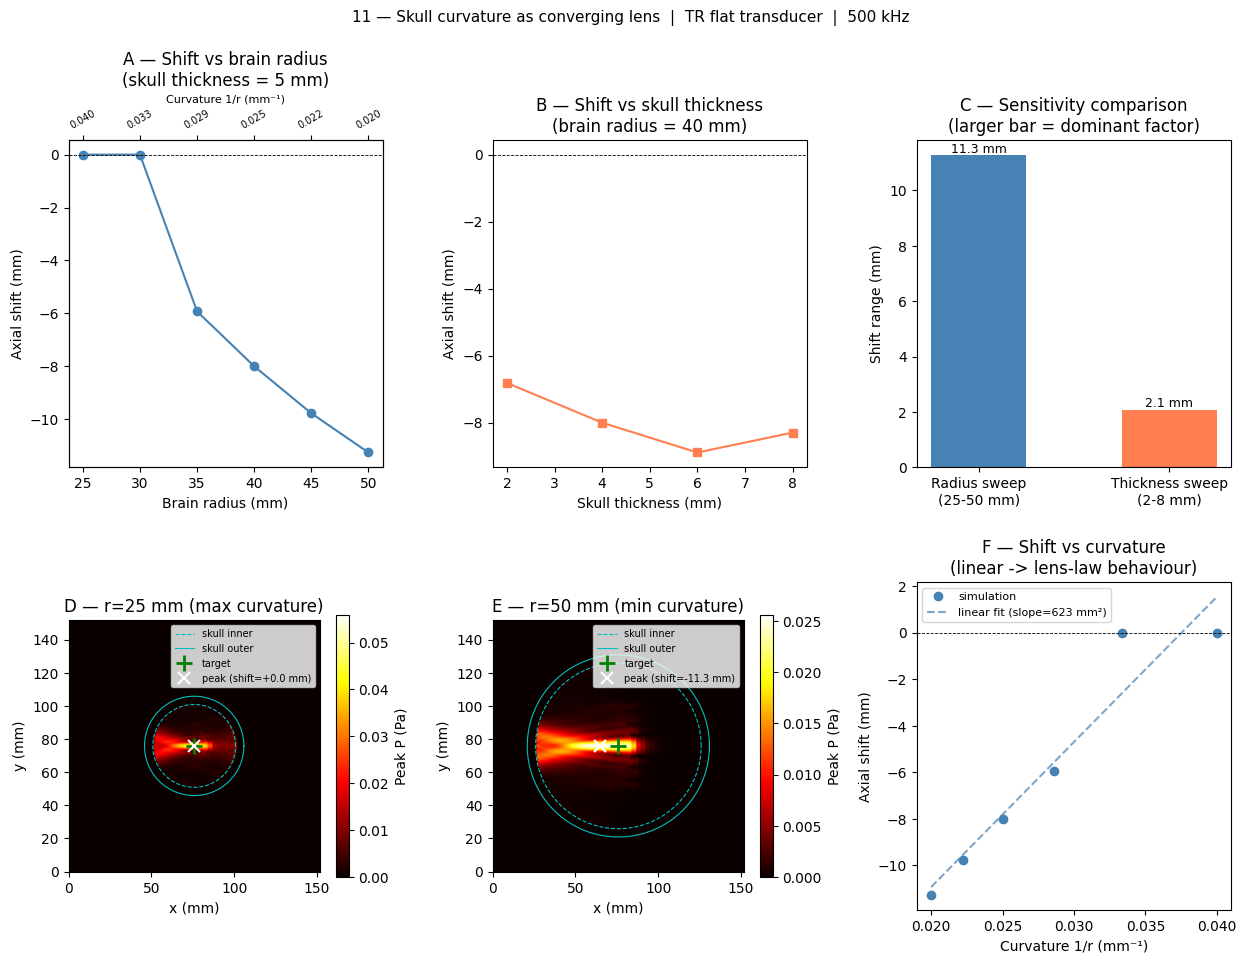


Practical implication:
To hit a target at depth d, aim at d + |shift(r)| deeper.
At r=40 mm: correct by 8.0 mm


In [1]:
# Self-contained.
#
# Each call to run_tr() runs:
#   1. Forward sim:  point source at brain centre -> flat transducer elements
#   2. Backward sim: time-reversed signals -> full-field p_max
# and returns the axial shift of the TR focus relative to the target.

# -- Shared acoustics / geometry
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq        = 500e3
dx          = (c_water / freq) / 10     # ~0.296 mm  (10 PPW)
Nx, Ny      = 512, 512
cx, cy      = Nx // 2, Ny // 2
standoff_mm = 5.0
aperture_mm = 30.0

# Verify kgrid timing (CFL=0.3, same for all configs since dx and c_skull fixed)
_kg_tmp = kWaveGrid([Nx, Ny], [dx, dx])
_kg_tmp.makeTime(c_skull, cfl=0.3)
print(f"Nt={_kg_tmp.Nt}  dt={_kg_tmp.dt:.2e} s  (same for all sweep configs)")


# -- TR helper -----------------------------------------------------------------
def run_tr(brain_r_mm, skull_t_mm, return_field=False):
    """Forward + TR-backward simulation.
    Returns axial_shift_mm (negative = closer to skull than target).
    If return_field=True also returns (p_max, brain_mask, skull_inner_px, skull_outer_px).
    """
    s_in  = brain_r_mm * 1e-3 / dx
    s_out = (brain_r_mm + skull_t_mm) * 1e-3 / dx

    XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
    R = np.sqrt((XX - cx)**2 + (YY - cy)**2)
    skull_m = (R >= s_in) & (R < s_out)
    brain_m = R < s_in

    ss  = np.full((Nx, Ny), c_water,  dtype=float)
    rho = np.full((Nx, Ny), rho_water, dtype=float)
    ss[skull_m] = c_skull;  rho[skull_m] = rho_skull
    ss[brain_m] = c_brain;  rho[brain_m] = rho_brain

    kg  = kWaveGrid([Nx, Ny], [dx, dx])
    kg.makeTime(c_skull, cfl=0.3)
    med = kWaveMedium(sound_speed=ss, density=rho)

    # Flat transducer: 5 mm standoff from skull outer surface
    tx   = cx - int(s_out) - int(standoff_mm * 1e-3 / dx)
    h_ap = int((aperture_mm / 2) * 1e-3 / dx)
    emask = np.zeros((Nx, Ny))
    for yi in range(cy - h_ap, cy + h_ap):
        emask[tx, int(yi)] = 1

    # Forward sim: point source at brain centre -> transducer elements
    src_f = kSource()
    src_f.p_mask = np.zeros((Nx, Ny));  src_f.p_mask[cx, cy] = 1
    src_f.p = tone_burst(1 / kg.dt, freq, 5).flatten()
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg, med, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    # Backward sim: time-reversed -> p_max everywhere
    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg, med, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    # Peak inside brain only
    p_br  = p_max.copy();  p_br[~brain_m] = 0
    peak_x_mm = np.unravel_index(np.argmax(p_br), (Nx, Ny))[0] * dx * 1e3
    shift = peak_x_mm - cx * dx * 1e3   # negative = closer to skull

    if return_field:
        return shift, p_max, brain_m, s_in, s_out
    return shift


# -- Sweep 1: brain radius  (skull thickness = 5 mm, fixed) -------------------
radii_mm = [25, 30, 35, 40, 45, 50]
t_fixed  = 5.0
shifts_r = []
fields_r = []   # store (p_max, brain_mask, s_in_px, s_out_px) per radius

print("\n=== SWEEP 1: brain radius  (skull thickness = 5 mm) ===")
for r in radii_mm:
    shift, p_max, bm, si, so = run_tr(r, t_fixed, return_field=True)
    shifts_r.append(shift)
    fields_r.append((p_max, bm, si, so))
    print(f"  r = {r:2.0f} mm  ->  axial shift = {shift:+.1f} mm")

# -- Sweep 2: skull thickness  (brain radius = 40 mm, fixed) ------------------
thicks_mm = [2, 4, 6, 8]
r_fixed   = 40.0
shifts_t  = []

print("\n=== SWEEP 2: skull thickness  (brain radius = 40 mm) ===")
for t in thicks_mm:
    shift = run_tr(r_fixed, t)
    shifts_t.append(shift)
    print(f"  t = {t:.0f} mm  ->  axial shift = {shift:+.1f} mm")

# -- Summary -------------------------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Radius sweep  : min shift = {min(shifts_r):+.1f} mm  (r={radii_mm[shifts_r.index(min(shifts_r))]} mm)")
print(f"               max shift = {max(shifts_r):+.1f} mm  (r={radii_mm[shifts_r.index(max(shifts_r))]} mm)")
print(f"Thickness sweep: range {min(shifts_t):+.1f} to {max(shifts_t):+.1f} mm")

dominant = "brain radius (curvature)" if (max(shifts_r)-min(shifts_r)) > (max(shifts_t)-min(shifts_t)) else "skull thickness"
print(f"Dominant factor: {dominant}")


# -- Plots ---------------------------------------------------------------------
theta = np.linspace(0, 2*np.pi, 360)
cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# ── Panel A: shift vs brain radius ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(radii_mm, shifts_r, 'o-', color='steelblue', lw=1.5, ms=6)
ax_a.axhline(0, color='k', lw=0.6, ls='--')
ax_a.set_xlabel('Brain radius (mm)')
ax_a.set_ylabel('Axial shift (mm)')
ax_a.set_title('A — Shift vs brain radius\n(skull thickness = 5 mm)')
# Secondary x-axis: curvature = 1/radius
ax_a2 = ax_a.twiny()
curv  = [1/r for r in radii_mm]
ax_a2.set_xlim(ax_a.get_xlim())
ax_a2.set_xticks(radii_mm)
ax_a2.set_xticklabels([f'{1/r:.3f}' for r in radii_mm], fontsize=7, rotation=30)
ax_a2.set_xlabel('Curvature 1/r (mm\u207b\xb9)', fontsize=8)

# ── Panel B: shift vs skull thickness ───────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(thicks_mm, shifts_t, 's-', color='coral', lw=1.5, ms=6)
ax_b.axhline(0, color='k', lw=0.6, ls='--')
ax_b.set_xlabel('Skull thickness (mm)')
ax_b.set_ylabel('Axial shift (mm)')
ax_b.set_title('B — Shift vs skull thickness\n(brain radius = 40 mm)')

# ── Panel C: combined summary bar chart ──────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
range_r = max(shifts_r) - min(shifts_r)
range_t = max(shifts_t) - min(shifts_t)
bars = ax_c.bar(['Radius sweep\n(25-50 mm)', 'Thickness sweep\n(2-8 mm)'],
                [range_r, range_t], color=['steelblue', 'coral'], width=0.5)
ax_c.set_ylabel('Shift range (mm)')
ax_c.set_title('C — Sensitivity comparison\n(larger bar = dominant factor)')
for bar, val in zip(bars, [range_r, range_t]):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.1f} mm', ha='center', fontsize=9)

# ── Panels D & E: focus maps for smallest and largest radius ─────────────────
for col, (r_idx, label) in enumerate([(0, f'r={radii_mm[0]} mm (max curvature)'),
                                       (-1, f'r={radii_mm[-1]} mm (min curvature)')]):
    p_max_i, bm_i, si_i, so_i = fields_r[r_idx]
    ax = fig.add_subplot(gs[1, col])
    p_br_i = p_max_i.copy();  p_br_i[~bm_i] = 0
    im = ax.imshow(p_br_i.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + si_i*dx*1e3*np.cos(theta), cy_mm + si_i*dx*1e3*np.sin(theta),
            'c--', lw=0.8, label='skull inner')
    ax.plot(cx_mm + so_i*dx*1e3*np.cos(theta), cy_mm + so_i*dx*1e3*np.sin(theta),
            'c-',  lw=0.8, label='skull outer')
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    peak_idx_i = np.unravel_index(np.argmax(p_br_i), (Nx, Ny))
    ax.plot(peak_idx_i[0]*dx*1e3, peak_idx_i[1]*dx*1e3, 'wx', ms=9, mew=1.5,
            label=f'peak (shift={shifts_r[r_idx]:+.1f} mm)')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"D" if col==0 else "E"} — {label}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel F: shift vs curvature (linear fit) ─────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
curvature = [1/r for r in radii_mm]
ax_f.plot(curvature, shifts_r, 'o', color='steelblue', ms=6, label='simulation')
# Linear fit
coeffs = np.polyfit(curvature, shifts_r, 1)
c_fit  = np.linspace(min(curvature), max(curvature), 100)
ax_f.plot(c_fit, np.polyval(coeffs, c_fit), '--', color='steelblue', alpha=0.7,
          label=f'linear fit (slope={coeffs[0]:.0f} mm\xb2)')
ax_f.axhline(0, color='k', lw=0.6, ls='--')
ax_f.set_xlabel('Curvature 1/r (mm\u207b\xb9)')
ax_f.set_ylabel('Axial shift (mm)')
ax_f.set_title('F — Shift vs curvature\n(linear -> lens-law behaviour)')
ax_f.legend(fontsize=8)

plt.suptitle('11 — Skull curvature as converging lens  |  TR flat transducer  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('11_skull_curvature_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPractical implication:")
print(f"To hit a target at depth d, aim at d + |shift(r)| deeper.")
print(f"At r={radii_mm[radii_mm.index(40)]} mm: correct by {abs(shifts_r[radii_mm.index(40)]):.1f} mm")


### 12_aperture_coverage_fix
Cell 11 showed the -8 mm shift grows with brain radius because the **flat transducer covers a progressively smaller solid angle** of the forward wavefront as the target depth increases. TR requires capturing the full wavefront — missing components bias the focus toward the near (skull) side.

Three remedies are compared head-to-head at the reference geometry (r=40 mm, skull=5 mm, 500 kHz):
1. **Wider aperture** — increase transducer width, standoff fixed at 5 mm
2. **Smaller standoff** — move transducer closer to the skull, aperture fixed at 30 mm
3. **Zero-crossing** — interpolate both curves to find the minimum aperture / maximum standoff that reduces the shift to ~0 mm

Nt=2414  dt=3.07e-08 s
Target: (75.9, 75.9) mm

=== SWEEP A: aperture  (standoff = 5 mm) ===
  ap= 20 mm  angle=11.4 deg  shift=-20.2 mm
  ap= 30 mm  angle=16.9 deg  shift=-8.0 mm
  ap= 45 mm  angle=24.4 deg  shift=-2.1 mm
  ap= 60 mm  angle=31.2 deg  shift=-0.6 mm
  ap= 75 mm  angle=37.1 deg  shift=-0.3 mm
  ap= 90 mm  angle=42.3 deg  shift=-0.3 mm

=== SWEEP B: standoff  (aperture = 30 mm) ===
  sd= 0.5 mm  angle=18.4 deg  shift=-6.2 mm
  sd= 1.0 mm  angle=18.2 deg  shift=-6.2 mm
  sd= 2.0 mm  angle=17.9 deg  shift=-6.5 mm
  sd= 5.0 mm  angle=16.9 deg  shift=-8.0 mm
  sd=10.0 mm  angle=15.4 deg  shift=-9.5 mm
  sd=20.0 mm  angle=13.1 deg  shift=-12.2 mm

=== ZERO CROSSINGS ===
Aperture: no zero crossing in sweep range
Standoff: no zero crossing in sweep range

Smallest shift in sweep A: -0.3 mm  (aperture=75 mm)
Smallest shift in sweep B: -6.2 mm  (standoff=0.5 mm)


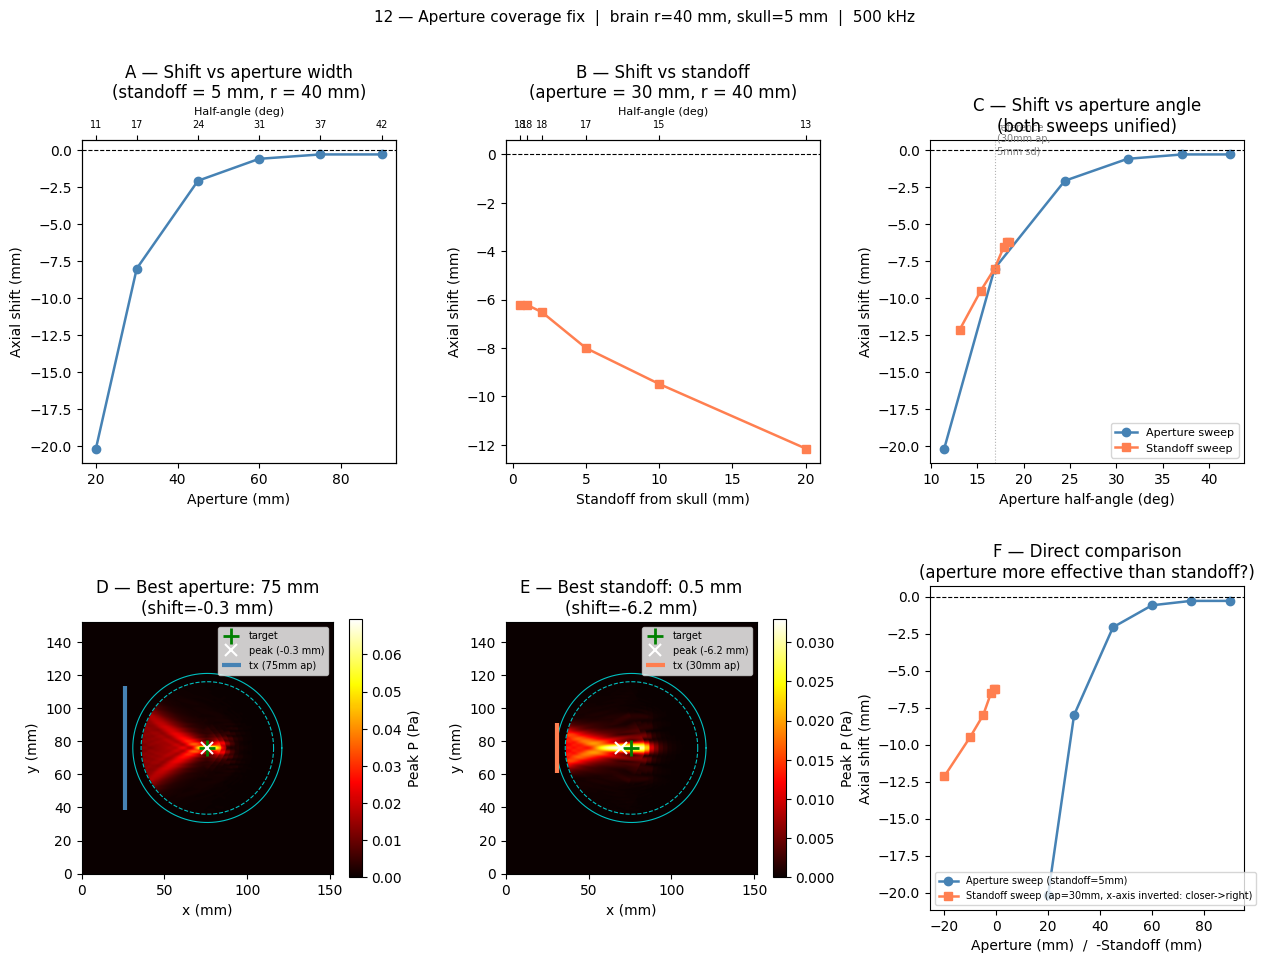


=== KEY FINDINGS ===
Aperture sweep: shift spans -20.2 to -0.3 mm
Standoff sweep: shift spans -12.2 to -6.2 mm
-> Aperture sweep did not reach zero (need > 90 mm)
-> Standoff sweep did not reach zero shift with 30mm aperture alone

Conclusion: panel C shows whether both sweeps collapse onto a single
aperture-angle curve. If yes, aperture angle is the sole predictor of focus quality.


In [ ]:
# Self-contained.  Fixed geometry: brain r=40 mm, skull=5 mm, water exterior.
# Two sweeps:
#   A — aperture width  (standoff = 5 mm fixed)
#   B — standoff        (aperture = 30 mm fixed)
# Each data point = 2 GPU sims (~3 s each).

# -- Shared parameters --------------------------------------------------------
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq           = 500e3
dx             = (c_water / freq) / 10     # ~0.296 mm
Nx, Ny         = 512, 512
cx, cy         = Nx // 2, Ny // 2
brain_r_mm     = 40.0
skull_t_mm     = 5.0
skull_in_px    = brain_r_mm * 1e-3 / dx
skull_out_px   = (brain_r_mm + skull_t_mm) * 1e-3 / dx

# Medium (same for every run)
XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R_grid = np.sqrt((XX - cx)**2 + (YY - cy)**2)
skull_m = (R_grid >= skull_in_px) & (R_grid < skull_out_px)
brain_m =  R_grid < skull_in_px

ss12  = np.full((Nx, Ny), c_water,  dtype=float)
rho12 = np.full((Nx, Ny), rho_water, dtype=float)
ss12[skull_m] = c_skull;  rho12[skull_m] = rho_skull
ss12[brain_m] = c_brain;  rho12[brain_m] = rho_brain

kg12 = kWaveGrid([Nx, Ny], [dx, dx])
kg12.makeTime(c_skull, cfl=0.3)
med12 = kWaveMedium(sound_speed=ss12, density=rho12)
print(f"Nt={kg12.Nt}  dt={kg12.dt:.2e} s")

target_x_mm = cx * dx * 1e3
print(f"Target: ({target_x_mm:.1f}, {cy*dx*1e3:.1f}) mm")


# -- TR helper ----------------------------------------------------------------
def run_tr12(aperture_mm, standoff_mm):
    """Returns axial_shift_mm and the peak p_max map inside the brain."""
    # Transducer: flat line at fixed x, standoff from skull outer surface
    standoff_px = max(1, int(standoff_mm * 1e-3 / dx))   # at least 1 grid pt
    tx          = cx - int(skull_out_px) - standoff_px
    h_ap        = int((aperture_mm / 2) * 1e-3 / dx)

    # Clip to valid grid range (stay inside PML boundary at +/-20 px)
    y_lo = max(20,      cy - h_ap)
    y_hi = min(Ny - 20, cy + h_ap)
    emask = np.zeros((Nx, Ny))
    emask[tx, y_lo:y_hi] = 1

    # Forward sim
    burst = tone_burst(1 / kg12.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[cx, cy] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg12, med12, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    # Backward sim
    src_b = kSource();  src_b.p_mask = emask.copy()
    src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg12, med12, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m] = 0
    peak_x = np.unravel_index(np.argmax(p_br), (Nx, Ny))[0] * dx * 1e3
    return peak_x - target_x_mm, p_max     # (shift_mm, field)


# =============================================================================
# SWEEP A — aperture width  (standoff = 5 mm)
# =============================================================================
apertures_mm  = [20, 30, 45, 60, 75, 90]
standoff_fixed = 5.0
shifts_A = [];  fields_A = []

print("\n=== SWEEP A: aperture  (standoff = 5 mm) ===")
for ap in apertures_mm:
    shift, pmap = run_tr12(ap, standoff_fixed)
    shifts_A.append(shift);  fields_A.append(pmap)
    # aperture angle (half-angle from transducer to target)
    dist_mm = (int(skull_out_px) + int(standoff_fixed * 1e-3 / dx)) * dx * 1e3
    angle_deg = np.degrees(np.arctan((ap / 2) / dist_mm))
    print(f"  ap={ap:3.0f} mm  angle={angle_deg:.1f} deg  shift={shift:+.1f} mm")

# =============================================================================
# SWEEP B — standoff  (aperture = 30 mm)
# =============================================================================
standoffs_mm  = [0.5, 1, 2, 5, 10, 20]
aperture_fixed = 30.0
shifts_B = [];  fields_B = []

print("\n=== SWEEP B: standoff  (aperture = 30 mm) ===")
for sd in standoffs_mm:
    shift, pmap = run_tr12(aperture_fixed, sd)
    shifts_B.append(shift);  fields_B.append(pmap)
    dist_mm = (int(skull_out_px) + max(1, int(sd * 1e-3 / dx))) * dx * 1e3
    angle_deg = np.degrees(np.arctan((aperture_fixed / 2) / dist_mm))
    print(f"  sd={sd:4.1f} mm  angle={angle_deg:.1f} deg  shift={shift:+.1f} mm")


# =============================================================================
# ANALYSIS C — zero-crossing for each sweep
# =============================================================================
def zero_crossing(x_vals, y_vals):
    for i in range(len(y_vals) - 1):
        if y_vals[i] * y_vals[i+1] <= 0:
            t = -y_vals[i] / (y_vals[i+1] - y_vals[i])
            return x_vals[i] + t * (x_vals[i+1] - x_vals[i])
    return None   # no crossing in range

zc_A = zero_crossing(apertures_mm,  shifts_A)
zc_B = zero_crossing(standoffs_mm,  shifts_B)

print("\n=== ZERO CROSSINGS ===")
print(f"Aperture zero-crossing : {zc_A:.1f} mm" if zc_A else "Aperture: no zero crossing in sweep range")
print(f"Standoff zero-crossing : {zc_B:.1f} mm" if zc_B else "Standoff: no zero crossing in sweep range")

# Best configurations found
best_A_idx = int(np.argmin(np.abs(shifts_A)))
best_B_idx = int(np.argmin(np.abs(shifts_B)))
print(f"\nSmallest shift in sweep A: {shifts_A[best_A_idx]:+.1f} mm  (aperture={apertures_mm[best_A_idx]} mm)")
print(f"Smallest shift in sweep B: {shifts_B[best_B_idx]:+.1f} mm  (standoff={standoffs_mm[best_B_idx]} mm)")


# =============================================================================
# PLOTS
# =============================================================================
theta = np.linspace(0, 2*np.pi, 360)
cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
r_in_mm  = skull_in_px  * dx * 1e3
r_out_mm = skull_out_px * dx * 1e3
extent   = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.35)

# Helper: aperture half-angle for each config
def ang_A(ap):
    d = (int(skull_out_px) + int(standoff_fixed * 1e-3 / dx)) * dx * 1e3
    return np.degrees(np.arctan((ap / 2) / d))

def ang_B(sd):
    d = (int(skull_out_px) + max(1, int(sd * 1e-3 / dx))) * dx * 1e3
    return np.degrees(np.arctan((aperture_fixed / 2) / d))

angles_A = [ang_A(ap) for ap in apertures_mm]
angles_B = [ang_B(sd) for sd in standoffs_mm]

# ── Panel A: shift vs aperture ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(apertures_mm, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6)
ax_a.axhline(0, color='k', lw=0.8, ls='--')
if zc_A:
    ax_a.axvline(x=zc_A, color='steelblue', lw=1, ls=':', alpha=0.7)
    ax_a.annotate(f'zero at\n{zc_A:.0f} mm', xy=(zc_A, 0),
                  xytext=(zc_A+3, min(shifts_A)*0.4),
                  fontsize=8, color='steelblue',
                  arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))
ax_a.set_xlabel('Aperture (mm)')
ax_a.set_ylabel('Axial shift (mm)')
ax_a.set_title('A — Shift vs aperture width\n(standoff = 5 mm, r = 40 mm)')
# Twin axis: aperture half-angle
ax_a2 = ax_a.twiny()
ax_a2.set_xlim(ax_a.get_xlim())
ax_a2.set_xticks(apertures_mm)
ax_a2.set_xticklabels([f'{ang_A(ap):.0f}' for ap in apertures_mm], fontsize=7)
ax_a2.set_xlabel('Half-angle (deg)', fontsize=8)

# ── Panel B: shift vs standoff ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(standoffs_mm, shifts_B, 's-', color='coral', lw=1.8, ms=6)
ax_b.axhline(0, color='k', lw=0.8, ls='--')
if zc_B:
    ax_b.axvline(x=zc_B, color='coral', lw=1, ls=':', alpha=0.7)
    ax_b.annotate(f'zero at\n{zc_B:.1f} mm', xy=(zc_B, 0),
                  xytext=(zc_B+1, min(shifts_B)*0.4),
                  fontsize=8, color='coral',
                  arrowprops=dict(arrowstyle='->', color='coral', lw=0.8))
ax_b.set_xlabel('Standoff from skull (mm)')
ax_b.set_ylabel('Axial shift (mm)')
ax_b.set_title('B — Shift vs standoff\n(aperture = 30 mm, r = 40 mm)')
ax_b2 = ax_b.twiny()
ax_b2.set_xlim(ax_b.get_xlim())
ax_b2.set_xticks(standoffs_mm)
ax_b2.set_xticklabels([f'{ang_B(sd):.0f}' for sd in standoffs_mm], fontsize=7)
ax_b2.set_xlabel('Half-angle (deg)', fontsize=8)

# ── Panel C: shift vs half-angle (both sweeps on same axis) ──────────────────
ax_c = fig.add_subplot(gs[0, 2])
ax_c.plot(angles_A, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6, label='Aperture sweep')
ax_c.plot(angles_B, shifts_B, 's-', color='coral',     lw=1.8, ms=6, label='Standoff sweep')
ax_c.axhline(0, color='k', lw=0.8, ls='--')
ax_c.set_xlabel('Aperture half-angle (deg)')
ax_c.set_ylabel('Axial shift (mm)')
ax_c.set_title('C — Shift vs aperture angle\n(both sweeps unified)')
ax_c.legend(fontsize=8)
# Mark reference at 30mm ap / 5mm standoff
ref_angle = ang_A(30)
ax_c.axvline(x=ref_angle, color='gray', lw=0.8, ls=':', alpha=0.6)
ax_c.text(ref_angle+0.3, max(shifts_A+shifts_B)*0.85, 'reference\n(30mm ap,\n5mm sd)',
          fontsize=7, color='gray')

# ── Panels D & E: best focus maps ────────────────────────────────────────────
for col, (idx_i, label_i, ap_i, sd_i, fields_i, color_i) in enumerate([
    (best_A_idx, f'Best aperture: {apertures_mm[best_A_idx]} mm\n(shift={shifts_A[best_A_idx]:+.1f} mm)',
     apertures_mm[best_A_idx], standoff_fixed, fields_A, 'steelblue'),
    (best_B_idx, f'Best standoff: {standoffs_mm[best_B_idx]} mm\n(shift={shifts_B[best_B_idx]:+.1f} mm)',
     aperture_fixed, standoffs_mm[best_B_idx], fields_B, 'coral'),
]):
    ax = fig.add_subplot(gs[1, col])
    p_br = fields_i[idx_i].copy();  p_br[~brain_m] = 0
    im = ax.imshow(p_br.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + r_in_mm*np.cos(theta),  cy_mm + r_in_mm*np.sin(theta),  'c--', lw=0.8)
    ax.plot(cx_mm + r_out_mm*np.cos(theta), cy_mm + r_out_mm*np.sin(theta), 'c-',  lw=0.8)
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    pk = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    ax.plot(pk[0]*dx*1e3, pk[1]*dx*1e3, 'wx', ms=9, mew=1.5,
            label=f'peak ({shifts_A[idx_i] if col==0 else shifts_B[idx_i]:+.1f} mm)')
    # Draw transducer segment
    sd_px = max(1, int((standoff_fixed if col==0 else ap_i)*1e-3/dx)) if col==1 else int(standoff_fixed*1e-3/dx)
    # Recompute properly
    sd_use = standoff_fixed if col == 0 else standoffs_mm[idx_i]
    ap_use = ap_i
    tx_px  = cx - int(skull_out_px) - max(1, int(sd_use * 1e-3 / dx))
    h_ap   = int((ap_use / 2) * 1e-3 / dx)
    y_lo_mm = max(20, cy - h_ap) * dx * 1e3
    y_hi_mm = min(Ny-20, cy + h_ap) * dx * 1e3
    ax.plot([tx_px*dx*1e3, tx_px*dx*1e3], [y_lo_mm, y_hi_mm],
            color=color_i, lw=3, solid_capstyle='butt',
            label=f'tx ({ap_use:.0f}mm ap)')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"D" if col==0 else "E"} — {label_i}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel F: summary — which approach is more efficient? ─────────────────────
ax_f = fig.add_subplot(gs[1, 2])

# Efficiency: shift improvement per mm of change in each parameter
# Aperture: from 30mm (baseline -8mm) to best_A
ap_baseline_idx = apertures_mm.index(30) if 30 in apertures_mm else 0
sd_baseline_idx = standoffs_mm.index(5)  if 5  in standoffs_mm else 3

ax_f.plot(apertures_mm, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6,
          label='Aperture sweep (standoff=5mm)')
ax_f.plot([sd * (-1) for sd in standoffs_mm], shifts_B, 's-', color='coral', lw=1.8, ms=6,
          label='Standoff sweep (ap=30mm, x-axis inverted: closer->right)')
ax_f.axhline(0, color='k', lw=0.8, ls='--')
ax_f.set_xlabel('Aperture (mm)  /  -Standoff (mm)')
ax_f.set_ylabel('Axial shift (mm)')
ax_f.set_title('F — Direct comparison\n(aperture more effective than standoff?)')
ax_f.legend(fontsize=7)

plt.suptitle('12 — Aperture coverage fix  |  brain r=40 mm, skull=5 mm  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('12_aperture_coverage_fix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== KEY FINDINGS ===")
print(f"Aperture sweep: shift spans {min(shifts_A):+.1f} to {max(shifts_A):+.1f} mm")
print(f"Standoff sweep: shift spans {min(shifts_B):+.1f} to {max(shifts_B):+.1f} mm")
if zc_A:
    print(f"-> Aperture needed for zero shift: ~{zc_A:.0f} mm at 5mm standoff")
else:
    print(f"-> Aperture sweep did not reach zero (need > {apertures_mm[-1]} mm)")
if zc_B:
    print(f"-> Standoff needed for zero shift: ~{zc_B:.1f} mm with 30mm aperture")
else:
    print(f"-> Standoff sweep did not reach zero shift with 30mm aperture alone")
print(f"\nConclusion: panel C shows whether both sweeps collapse onto a single")
print(f"aperture-angle curve. If yes, aperture angle is the sole predictor of focus quality.")


### 13_best_config_and_steering
Two parts:

**Part 1** — Combine the best settings from cell 12: aperture=90 mm + standoff=0 (transducer touching the skull). This gives a 45 deg half-angle, the maximum achievable with the flat geometry at r=40 mm.

**Part 2** — Off-axis steering sweep using the best config. Targets are moved laterally (y-axis) and axially (x-axis, toward/away from transducer) to map out the focusable region of the brain. This answers: *how far from the centre can we reliably steer?*

Nt=2414  dt=3.07e-08 s

PART 1 — centre focus comparison
  Baseline  (ap=30 mm, sd=5 mm): shift=-8.0 mm  error=8.0 mm
  Best      (ap=90 mm, sd=0 mm): shift=-0.3 mm  error=0.3 mm

PART 2a — lateral (y) steering  (ap=90 mm, sd=0 mm)
  dy=-20 mm  peak=(75.9, 56.0) mm  err=0.0 mm  (sx=+0.0, sy=+0.0)
  dy=-15 mm  peak=(75.6, 61.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=-10 mm  peak=(75.6, 66.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= -5 mm  peak=(75.6, 71.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= +0 mm  peak=(75.6, 75.9) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= +5 mm  peak=(75.6, 80.6) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+10 mm  peak=(75.6, 85.7) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+15 mm  peak=(75.6, 90.7) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+20 mm  peak=(75.9, 95.7) mm  err=0.0 mm  (sx=+0.0, sy=+0.0)

PART 2b — axial (x) steering  (ap=90 mm, sd=0 mm)
  dx=-25 mm  target=(51.0, 75.9)  peak=(51.3, 75.9)  err=0.3 mm
  dx=-15 mm  target=(61.1, 75.9)  peak=(61.1, 75.9)  err=0.

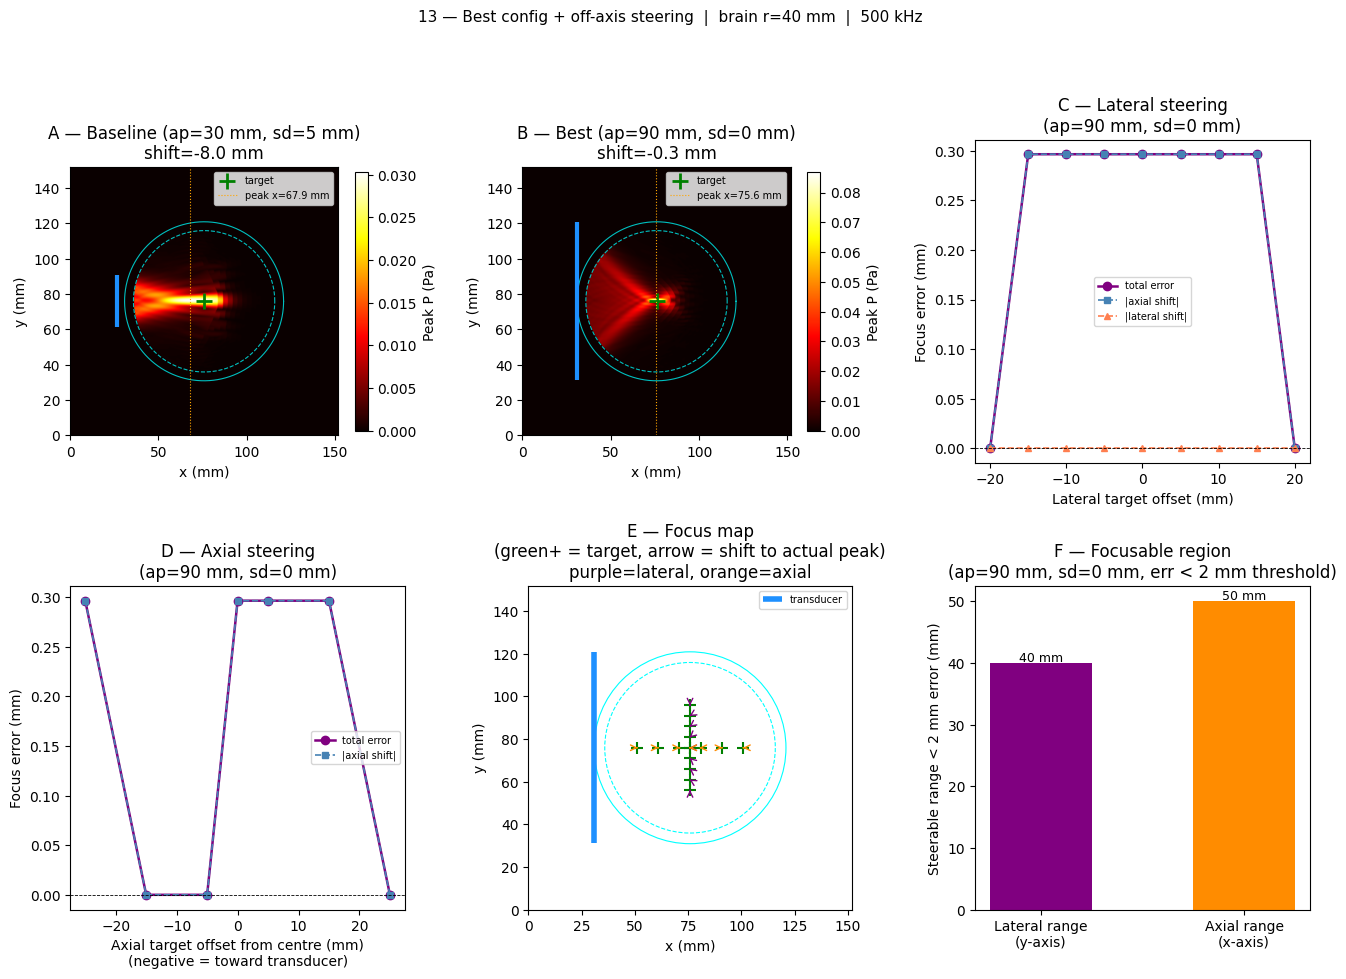


=== PART 1 SUMMARY ===
Baseline (ap=30 mm, sd=5 mm): axial shift = -8.0 mm
Best     (ap=90 mm, sd=0 mm): axial shift = -0.3 mm
Improvement: 7.7 mm closer to target

=== PART 2 SUMMARY ===
Lateral steering (err < 2 mm): 40 mm range  (+/-20 mm)
Axial steering   (err < 2 mm): 50 mm range  (from 51 to 101 mm)


In [ ]:
# Self-contained.  r=40 mm brain, skull=5 mm, water exterior, 500 kHz.
#
# PART 1: best flat-transducer config (ap=90 mm, standoff=0) vs baseline (ap=30 mm, sd=5 mm)
# PART 2: lateral (y) and axial (x) steering sweep with the best config

# -- Shared medium (built once) -----------------------------------------------
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq         = 500e3
dx           = (c_water / freq) / 10
Nx, Ny       = 512, 512
cx, cy       = Nx // 2, Ny // 2
brain_r_mm   = 40.0
skull_t_mm   = 5.0
skull_in_px  = brain_r_mm * 1e-3 / dx
skull_out_px = (brain_r_mm + skull_t_mm) * 1e-3 / dx

XX, YY   = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R_grid   = np.sqrt((XX - cx)**2 + (YY - cy)**2)
skull_m  = (R_grid >= skull_in_px) & (R_grid < skull_out_px)
brain_m  = R_grid < skull_in_px

ss13  = np.full((Nx, Ny), c_water,  dtype=float)
rho13 = np.full((Nx, Ny), rho_water, dtype=float)
ss13[skull_m] = c_skull;   rho13[skull_m] = rho_skull
ss13[brain_m] = c_brain;   rho13[brain_m] = rho_brain

kg13  = kWaveGrid([Nx, Ny], [dx, dx])
kg13.makeTime(c_skull, cfl=0.3)
med13 = kWaveMedium(sound_speed=ss13, density=rho13)
print(f"Nt={kg13.Nt}  dt={kg13.dt:.2e} s")

cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
r_in_mm  = skull_in_px  * dx * 1e3
r_out_mm = skull_out_px * dx * 1e3

# -- TR helper ----------------------------------------------------------------
def run_tr13(target_x_px, target_y_px, ap_mm, standoff_mm):
    """TR focus at arbitrary brain target.
    Returns (shift_x_mm, shift_y_mm, error_mm, peak_x_mm, peak_y_mm, p_max_brain).
    """
    sd_px = max(1, int(standoff_mm * 1e-3 / dx))
    tx    = cx - int(skull_out_px) - sd_px
    h_ap  = int((ap_mm / 2) * 1e-3 / dx)
    y_lo  = max(20,      cy - h_ap)
    y_hi  = min(Ny - 20, cy + h_ap)

    emask = np.zeros((Nx, Ny))
    emask[tx, y_lo:y_hi] = 1

    burst = tone_burst(1 / kg13.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(target_x_px), int(target_y_px)] = 1
    src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg13, med13, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    src_b = kSource();  src_b.p_mask = emask.copy()
    src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg13, med13, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x  = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    tg_x  = target_x_px * dx * 1e3;  tg_y = target_y_px * dx * 1e3
    sx    = pk_x - tg_x;  sy = pk_y - tg_y
    err   = np.sqrt(sx**2 + sy**2)
    return sx, sy, err, pk_x, pk_y, p_br


# =============================================================================
# PART 1 — best config (ap=90 mm, standoff=0) at brain centre
# =============================================================================
AP_BEST = 90.0;  SD_BEST = 0.0   # standoff=0 -> 1 grid point gap
AP_BASE = 30.0;  SD_BASE = 5.0

print("\nPART 1 — centre focus comparison")
sx_base, _, err_base, pk_x_base, _, p_base = run_tr13(cx, cy, AP_BASE, SD_BASE)
print(f"  Baseline  (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm): shift={sx_base:+.1f} mm  error={err_base:.1f} mm")

sx_best, _, err_best, pk_x_best, _, p_best = run_tr13(cx, cy, AP_BEST, SD_BEST)
print(f"  Best      (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm): shift={sx_best:+.1f} mm  error={err_best:.1f} mm")


# =============================================================================
# PART 2 — off-axis steering  (best config: ap=90 mm, standoff=0)
# =============================================================================
# Lateral (y) targets: y offsets from brain centre, x fixed at cx
lat_offsets_mm = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
lat_results = []   # (tgt_y_mm, peak_x_mm, peak_y_mm, err_mm, sx, sy)

print("\nPART 2a — lateral (y) steering  (ap=90 mm, sd=0 mm)")
for dy_mm in lat_offsets_mm:
    ty = cy + int(dy_mm * 1e-3 / dx)
    if not brain_m[cx, ty]:
        print(f"  dy={dy_mm:+.0f} mm  outside brain — skipped")
        lat_results.append(None);  continue
    sx, sy, err, pk_x, pk_y, _ = run_tr13(cx, ty, AP_BEST, SD_BEST)
    lat_results.append((dy_mm, pk_x, pk_y, err, sx, sy))
    print(f"  dy={dy_mm:+3.0f} mm  peak=({pk_x:.1f}, {pk_y:.1f}) mm  err={err:.1f} mm  (sx={sx:+.1f}, sy={sy:+.1f})")

# Axial (x) targets: x offsets from brain centre, y fixed at cy
axial_offsets_mm = [-25, -15, -5, 0, 5, 15, 25]
axial_results = []  # (dx_mm, peak_x_mm, peak_y_mm, err_mm, sx, sy)

print("\nPART 2b — axial (x) steering  (ap=90 mm, sd=0 mm)")
for dx_mm in axial_offsets_mm:
    tx_px = cx + int(dx_mm * 1e-3 / dx)
    if not brain_m[tx_px, cy]:
        print(f"  dx={dx_mm:+.0f} mm  outside brain — skipped")
        axial_results.append(None);  continue
    sx, sy, err, pk_x, pk_y, _ = run_tr13(tx_px, cy, AP_BEST, SD_BEST)
    axial_results.append((dx_mm, pk_x, pk_y, err, sx, sy))
    tgt_x_mm = tx_px * dx * 1e3
    print(f"  dx={dx_mm:+3.0f} mm  target=({tgt_x_mm:.1f}, {cy_mm:.1f})  peak=({pk_x:.1f}, {pk_y:.1f})  err={err:.1f} mm")


# =============================================================================
# PLOTS
# =============================================================================
theta = np.linspace(0, 2*np.pi, 360)
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.35)

# ── Panel A: baseline vs best focus maps side by side ────────────────────────
for col, (pmap, label, shift_val) in enumerate([
    (p_base, f'Baseline (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm)\nshift={sx_base:+.1f} mm', sx_base),
    (p_best, f'Best (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm)\nshift={sx_best:+.1f} mm',     sx_best),
]):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(pmap.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + r_in_mm*np.cos(theta),  cy_mm + r_in_mm*np.sin(theta),  'c--', lw=0.8)
    ax.plot(cx_mm + r_out_mm*np.cos(theta), cy_mm + r_out_mm*np.sin(theta), 'c-',  lw=0.8)
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    pk_val = pk_x_base if col == 0 else pk_x_best
    ax.axvline(x=pk_val, color='orange', lw=0.8, ls=':', label=f'peak x={pk_val:.1f} mm')
    sd_px_col = int(SD_BASE * 1e-3 / dx) if col == 0 else max(1, int(SD_BEST * 1e-3 / dx))
    ap_col    = AP_BASE if col == 0 else AP_BEST
    tx_col    = cx - int(skull_out_px) - sd_px_col
    h_ap_col  = int((ap_col / 2) * 1e-3 / dx)
    ax.plot([tx_col*dx*1e3]*2,
            [max(20, cy-h_ap_col)*dx*1e3, min(Ny-20, cy+h_ap_col)*dx*1e3],
            color='dodgerblue', lw=3, solid_capstyle='butt')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"A" if col==0 else "B"} — {label}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel C: lateral steering — targeting error vs y offset ──────────────────
ax_c = fig.add_subplot(gs[0, 2])
lat_valid = [r for r in lat_results if r is not None]
lat_dy  = [r[0] for r in lat_valid]
lat_err = [r[3] for r in lat_valid]
lat_sx  = [r[4] for r in lat_valid]
lat_sy  = [r[5] for r in lat_valid]

ax_c.plot(lat_dy, lat_err, 'o-', color='purple', lw=1.8, ms=6, label='total error')
ax_c.plot(lat_dy, [abs(s) for s in lat_sx], 's--', color='steelblue', lw=1.2, ms=5, label='|axial shift|')
ax_c.plot(lat_dy, [abs(s) for s in lat_sy], '^--', color='coral',     lw=1.2, ms=5, label='|lateral shift|')
ax_c.axhline(0, color='k', lw=0.6, ls='--')
ax_c.set_xlabel('Lateral target offset (mm)');  ax_c.set_ylabel('Focus error (mm)')
ax_c.set_title('C — Lateral steering\n(ap=90 mm, sd=0 mm)')
ax_c.legend(fontsize=7)

# ── Panel D: axial steering — targeting error vs x offset ────────────────────
ax_d = fig.add_subplot(gs[1, 0])
ax_valid = [r for r in axial_results if r is not None]
ax_dx   = [r[0] for r in ax_valid]
ax_err  = [r[3] for r in ax_valid]
ax_sx   = [r[4] for r in ax_valid]

ax_d.plot(ax_dx, ax_err, 'o-', color='purple', lw=1.8, ms=6, label='total error')
ax_d.plot(ax_dx, [abs(s) for s in ax_sx], 's--', color='steelblue', lw=1.2, ms=5, label='|axial shift|')
ax_d.axhline(0, color='k', lw=0.6, ls='--')
ax_d.set_xlabel('Axial target offset from centre (mm)\n(negative = toward transducer)')
ax_d.set_ylabel('Focus error (mm)')
ax_d.set_title('D — Axial steering\n(ap=90 mm, sd=0 mm)')
ax_d.legend(fontsize=7)

# ── Panel E: 2D focusable region map ─────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
# Draw brain/skull boundary
ax_e.add_patch(plt.Circle((cx_mm, cy_mm), r_in_mm,  fill=False, linestyle='--', color='cyan', lw=0.8))
ax_e.add_patch(plt.Circle((cx_mm, cy_mm), r_out_mm, fill=False, linestyle='-',  color='cyan', lw=0.8))

# Transducer (best config)
sd_best_px = max(1, int(SD_BEST * 1e-3 / dx))
tx_best    = cx - int(skull_out_px) - sd_best_px
h_ap_best  = int((AP_BEST / 2) * 1e-3 / dx)
ax_e.plot([tx_best*dx*1e3]*2,
          [max(20, cy-h_ap_best)*dx*1e3, min(Ny-20, cy+h_ap_best)*dx*1e3],
          color='dodgerblue', lw=4, solid_capstyle='butt', label='transducer')

# Lateral steering arrows
for res in lat_valid:
    dy_mm, pk_x, pk_y, err, sx, sy = res
    tgt_x = cx_mm;  tgt_y = cy_mm + dy_mm
    ax_e.plot(tgt_x, tgt_y, 'g+', ms=8, mew=1.5)
    ax_e.annotate('', xy=(pk_x, pk_y), xytext=(tgt_x, tgt_y),
                  arrowprops=dict(arrowstyle='->', color='purple', lw=1.0))

# Axial steering arrows
for res in ax_valid:
    dx_mm, pk_x, pk_y, err, sx, sy = res
    tgt_x = cx_mm + dx_mm;  tgt_y = cy_mm
    ax_e.plot(tgt_x, tgt_y, 'g+', ms=8, mew=1.5)
    ax_e.annotate('', xy=(pk_x, pk_y), xytext=(tgt_x, tgt_y),
                  arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0))

ax_e.set_xlim(0, Nx*dx*1e3);  ax_e.set_ylim(0, Ny*dx*1e3)
ax_e.set_aspect('equal')
ax_e.set_xlabel('x (mm)');  ax_e.set_ylabel('y (mm)')
ax_e.set_title('E — Focus map\n(green+ = target, arrow = shift to actual peak)\npurple=lateral, orange=axial')
ax_e.legend(fontsize=7, loc='upper right')

# ── Panel F: max steerable range summary ─────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
# Threshold: "good focus" if error < 2mm
thresh = 2.0
lat_good = [r[0] for r in lat_valid if r[3] < thresh]
ax_good  = [r[0] for r in ax_valid  if r[3] < thresh]

bar_labels = ['Lateral range\n(y-axis)', 'Axial range\n(x-axis)']
if lat_good:
    lat_range = max(lat_good) - min(lat_good)
else:
    lat_range = 0
if ax_good:
    ax_range = max(ax_good) - min(ax_good)
else:
    ax_range = 0

bars = ax_f.bar(bar_labels, [lat_range, ax_range], color=['purple', 'darkorange'], width=0.5)
ax_f.set_ylabel('Steerable range < 2 mm error (mm)')
ax_f.set_title(f'F — Focusable region\n(ap=90 mm, sd=0 mm, err < {thresh:.0f} mm threshold)')
for bar, val in zip(bars, [lat_range, ax_range]):
    ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.0f} mm', ha='center', fontsize=9)

plt.suptitle('13 — Best config + off-axis steering  |  brain r=40 mm  |  500 kHz', fontsize=11, y=1.01)
plt.savefig('13_steering_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== PART 1 SUMMARY ===")
print(f"Baseline (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm): axial shift = {sx_base:+.1f} mm")
print(f"Best     (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm): axial shift = {sx_best:+.1f} mm")
print(f"Improvement: {abs(sx_base) - abs(sx_best):.1f} mm closer to target")

print("\n=== PART 2 SUMMARY ===")
print(f"Lateral steering (err < {thresh:.0f} mm): {lat_range:.0f} mm range  "
      + (f"(+/-{lat_range/2:.0f} mm)" if lat_range > 0 else "(none)"))
print(f"Axial steering   (err < {thresh:.0f} mm): {ax_range:.0f} mm range  "
      + (f"(from {cx_mm+min(ax_good):.0f} to {cx_mm+max(ax_good):.0f} mm)" if ax_good else "(none)"))


### 14_random_targets
Pick 5 random targets inside the brain and try to hit each one using TR, with the flat transducer repositioned and rotated to face each target optimally (placed on the opposite side of the skull).

Three strategies are compared for each target:
- **Optimal**: single transducer facing the target directly
- **Perpendicular**: single transducer rotated 90 deg from optimal
- **Combined**: both transducers simultaneously (both directions at once)

The combined case answers whether running the sim from both directions helps when the optimal placement already works well.

Nt=2414  dt=3.07e-08 s

Targets:
  1: (89.6, 71.5) mm  r=14.4 mm  angle=342 deg
  2: (56.9, 62.3) mm  r=23.3 mm  angle=216 deg
  3: (80.8, 83.3) mm  r=8.9 mm  angle=56 deg
  4: (80.2, 71.1) mm  r=6.5 mm  angle=312 deg
  5: (70.7, 56.5) mm  r=20.0 mm  angle=255 deg

Target 1 (89.6, 71.5) mm
  Optimal      err=0.3 mm  (sx=+0.3, sy=+0.0)
  Perpendicular err=0.0 mm  (sx=+0.0, sy=+0.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 2 (56.9, 62.3) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)
  Perpendicular err=5.1 mm  (sx=+0.6, sy=+5.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 3 (80.8, 83.3) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)
  Perpendicular err=0.4 mm  (sx=+0.3, sy=-0.3)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 4 (80.2, 71.1) mm
  Optimal      err=0.4 mm  (sx=-0.3, sy=+0.3)
  Perpendicular err=0.0 mm  (sx=+0.0, sy=+0.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 5 (70.7, 56.5) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)

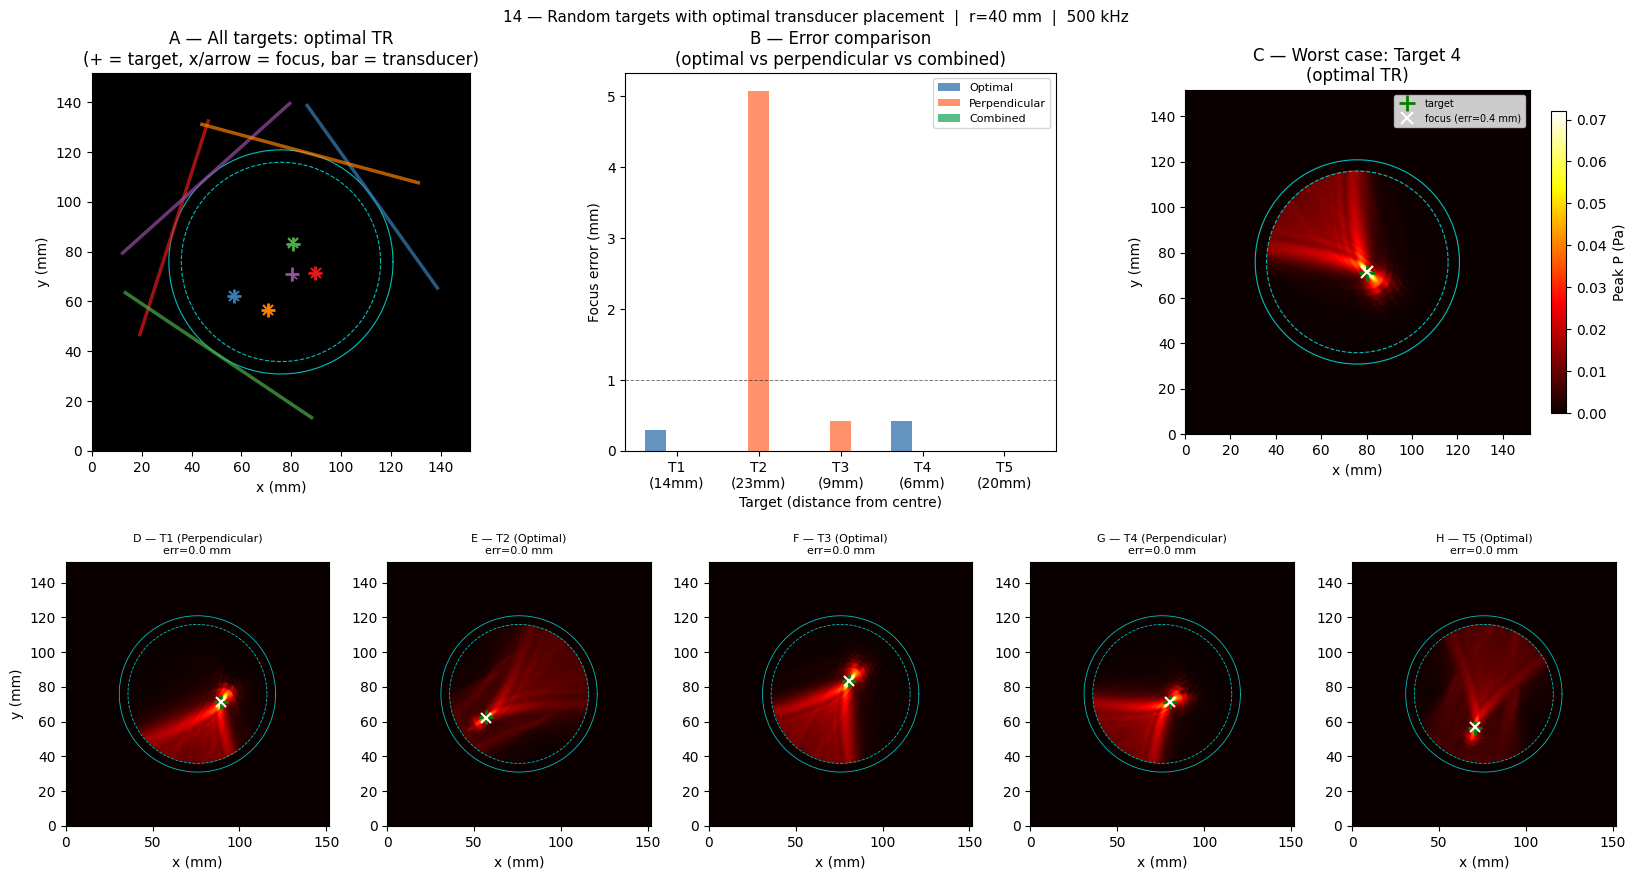


=== SUMMARY ===
  Target   r (mm)   angle    Optimal       Perp   Combined  Best
  T1       14.4    342 deg       0.3       0.0       0.0  Perpendicular
  T2       23.3    216 deg       0.0       5.1       0.0  Optimal
  T3        8.9     56 deg       0.0       0.4       0.0  Optimal
  T4        6.5    312 deg       0.4       0.0       0.0  Perpendicular
  T5       20.0    255 deg       0.0       0.0       0.0  Optimal

Mean error — Optimal: 0.14 mm | Perpendicular: 1.10 mm | Combined: 0.00 mm


In [ ]:
# Self-contained.
# 5 random targets; 3 TR strategies each; 6 sims per target; ~30 sims total (~90 s).

# -- Medium setup (same as cells 10-13) ---------------------------------------
c_water  = 1482.0;  rho_water = 1000.0
c_skull  = 2900.0;  rho_skull = 1900.0
c_brain  = 1560.0;  rho_brain = 1040.0
freq     = 500e3
dx       = (c_water / freq) / 10
Nx, Ny   = 512, 512
cx, cy   = Nx // 2, Ny // 2
BRAIN_R  = 40.0;   SKULL_T = 5.0
s_in14   = BRAIN_R               * 1e-3 / dx
s_out14  = (BRAIN_R + SKULL_T)   * 1e-3 / dx
cx_mm14  = cx * dx * 1e3;   cy_mm14 = cy * dx * 1e3

XX14, YY14 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R14     = np.sqrt((XX14 - cx)**2 + (YY14 - cy)**2)
skull_m14 = (R14 >= s_in14) & (R14 < s_out14)
brain_m14 =  R14 <  s_in14

ss14    = np.full((Nx, Ny), c_water,  dtype=float)
rho14   = np.full((Nx, Ny), rho_water, dtype=float)
ss14[skull_m14] = c_skull;   rho14[skull_m14] = rho_skull
ss14[brain_m14] = c_brain;   rho14[brain_m14] = rho_brain

kg14    = kWaveGrid([Nx, Ny], [dx, dx])
kg14.makeTime(c_skull, cfl=0.3)
med14   = kWaveMedium(sound_speed=ss14, density=rho14)
print(f"Nt={kg14.Nt}  dt={kg14.dt:.2e} s")


# -- Helpers ------------------------------------------------------------------
def build_tx_mask14(face_angle_rad, ap_mm, sd_mm):
    """Flat transducer facing direction face_angle_rad (= direction from centre to target).
    Transducer is placed on the OPPOSITE side: centre at angle face_angle_rad + pi.
    Elements lie perpendicular to the approach axis.
    """
    sd_px  = max(1, int(sd_mm * 1e-3 / dx))
    h_ap   = int((ap_mm / 2) * 1e-3 / dx)
    r_tx   = int(s_out14) + sd_px
    tx_ang = face_angle_rad + np.pi          # transducer side
    tc_x   = cx + r_tx * np.cos(tx_ang)
    tc_y   = cy + r_tx * np.sin(tx_ang)
    perp_x = -np.sin(tx_ang)                 # perpendicular to approach axis
    perp_y =  np.cos(tx_ang)
    mask   = np.zeros((Nx, Ny))
    for k in range(-h_ap, h_ap + 1):
        xi = int(round(tc_x + k * perp_x))
        yi = int(round(tc_y + k * perp_y))
        if 20 <= xi < Nx - 20 and 20 <= yi < Ny - 20:
            mask[xi, yi] = 1
    return mask


def run_tr14(tgt_x_px, tgt_y_px, emask):
    """Two-sim TR with given element mask.
    Returns (shift_x_mm, shift_y_mm, error_mm, peak_x_mm, peak_y_mm, p_brain).
    """
    burst = tone_burst(1 / kg14.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(tgt_x_px), int(tgt_y_px)] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_fwd = kspaceFirstOrder(kg14, med14, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_fwd[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg14, med14, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m14] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    sx = pk_x - tgt_x_px * dx * 1e3
    sy = pk_y - tgt_y_px * dx * 1e3
    return sx, sy, np.sqrt(sx**2 + sy**2), pk_x, pk_y, p_br


# -- Generate 5 random targets ------------------------------------------------
np.random.seed(42)
AP14 = 90.0;  SD14 = 0.0
targets14 = []
while len(targets14) < 5:
    r_mm    = np.random.uniform(5, BRAIN_R - 10)
    angle   = np.random.uniform(0, 2 * np.pi)
    tx_mm   = cx_mm14 + r_mm * np.cos(angle)
    ty_mm   = cy_mm14 + r_mm * np.sin(angle)
    tx_px   = int(round(tx_mm / (dx * 1e3)))
    ty_px   = int(round(ty_mm / (dx * 1e3)))
    if brain_m14[tx_px, ty_px]:
        targets14.append({
            'x_mm': tx_mm, 'y_mm': ty_mm,
            'x_px': tx_px, 'y_px': ty_px,
            'face_angle': angle, 'r_mm': r_mm
        })

print("\nTargets:")
for i, t in enumerate(targets14):
    print(f"  {i+1}: ({t['x_mm']:.1f}, {t['y_mm']:.1f}) mm  "
          f"r={t['r_mm']:.1f} mm  angle={np.degrees(t['face_angle']):.0f} deg")


# -- Run TR: 3 strategies per target ------------------------------------------
# optimal = transducer directly facing target
# perp    = transducer rotated 90 deg from optimal
# combined = both transducers simultaneously (forward records both, backward replays both)

results14 = []
for i, tgt in enumerate(targets14):
    fa = tgt['face_angle']
    print(f"\nTarget {i+1} ({tgt['x_mm']:.1f}, {tgt['y_mm']:.1f}) mm")

    m_opt  = build_tx_mask14(fa,           AP14, SD14)
    m_perp = build_tx_mask14(fa + np.pi/2, AP14, SD14)
    m_both = np.clip(m_opt + m_perp, 0, 1)

    r_opt  = run_tr14(tgt['x_px'], tgt['y_px'], m_opt)
    print(f"  Optimal      err={r_opt[2]:.1f} mm  (sx={r_opt[0]:+.1f}, sy={r_opt[1]:+.1f})")

    r_perp = run_tr14(tgt['x_px'], tgt['y_px'], m_perp)
    print(f"  Perpendicular err={r_perp[2]:.1f} mm  (sx={r_perp[0]:+.1f}, sy={r_perp[1]:+.1f})")

    r_both = run_tr14(tgt['x_px'], tgt['y_px'], m_both)
    print(f"  Combined      err={r_both[2]:.1f} mm  (sx={r_both[0]:+.1f}, sy={r_both[1]:+.1f})")

    results14.append({
        'tgt': tgt,
        'masks': (m_opt, m_perp, m_both),
        'opt': r_opt, 'perp': r_perp, 'both': r_both
    })


# -- Plots --------------------------------------------------------------------
theta14   = np.linspace(0, 2 * np.pi, 360)
r_in_mm14 = s_in14  * dx * 1e3
r_out_mm14= s_out14 * dx * 1e3
extent14  = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
colors5   = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
labels_method = ['Optimal', 'Perpendicular', 'Combined']

fig = plt.figure(figsize=(20, 9))
gs_top = fig.add_gridspec(1, 3, top=0.94, bottom=0.52, wspace=0.30)
gs_bot = fig.add_gridspec(1, 5, top=0.46, bottom=0.04, wspace=0.22)

# ── Panel A: vector map (all 5 targets, optimal TR result) ───────────────────
ax_a = fig.add_subplot(gs_top[0, 0])
ax_a.set_facecolor('k')
ax_a.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),
          'c--', lw=0.8)
ax_a.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14),
          'c-',  lw=0.8)

for i, res in enumerate(results14):
    tgt   = res['tgt']
    sx_o, sy_o, err_o, pkx_o, pky_o, _ = res['opt']

    # Target marker
    ax_a.plot(tgt['x_mm'], tgt['y_mm'], '+', color=colors5[i], ms=10, mew=2)

    # Arrow from target to actual focus (optimal)
    if err_o > 0.4:
        ax_a.annotate('', xy=(pkx_o, pky_o), xytext=(tgt['x_mm'], tgt['y_mm']),
                      arrowprops=dict(arrowstyle='->', color=colors5[i], lw=1.2))
    else:
        ax_a.plot(pkx_o, pky_o, 'x', color=colors5[i], ms=7, mew=1.5)

    # Transducer arc
    fa = tgt['face_angle']
    tx_ang = fa + np.pi
    r_tx   = int(s_out14) + max(1, int(SD14 * 1e-3 / dx))
    tc_x_mm = (cx + r_tx * np.cos(tx_ang)) * dx * 1e3
    tc_y_mm = (cy + r_tx * np.sin(tx_ang)) * dx * 1e3
    perp_x_mm = -np.sin(tx_ang) * AP14 / 2
    perp_y_mm =  np.cos(tx_ang) * AP14 / 2
    ax_a.plot([tc_x_mm - perp_x_mm, tc_x_mm + perp_x_mm],
              [tc_y_mm - perp_y_mm, tc_y_mm + perp_y_mm],
              '-', color=colors5[i], lw=2.5, alpha=0.7)

ax_a.set_xlim(0, Nx*dx*1e3);  ax_a.set_ylim(0, Ny*dx*1e3)
ax_a.set_aspect('equal')
ax_a.set_xlabel('x (mm)');  ax_a.set_ylabel('y (mm)')
ax_a.set_title('A — All targets: optimal TR\n(+ = target, x/arrow = focus, bar = transducer)')

# ── Panel B: grouped error bar chart -----------------------------------------
ax_b = fig.add_subplot(gs_top[0, 1])
x_tgt  = np.arange(5)
w      = 0.26
errs   = [[res['opt'][2], res['perp'][2], res['both'][2]] for res in results14]
bar_cols = ['steelblue', 'coral', 'mediumseagreen']

for mi, (mc, ml) in enumerate(zip(bar_cols, labels_method)):
    vals = [errs[ti][mi] for ti in range(5)]
    ax_b.bar(x_tgt + (mi - 1) * w, vals, width=w, color=mc, label=ml, alpha=0.85)

ax_b.set_xticks(x_tgt)
ax_b.set_xticklabels([f'T{i+1}\n({results14[i]["tgt"]["r_mm"]:.0f}mm)' for i in range(5)])
ax_b.set_xlabel('Target (distance from centre)')
ax_b.set_ylabel('Focus error (mm)')
ax_b.set_title('B — Error comparison\n(optimal vs perpendicular vs combined)')
ax_b.legend(fontsize=8)
ax_b.axhline(1.0, color='k', lw=0.7, ls='--', alpha=0.5)

# ── Panel C: worst-case focus map (target with max optimal error) -------------
worst_idx = int(np.argmax([res['opt'][2] for res in results14]))
res_w = results14[worst_idx]
ax_c = fig.add_subplot(gs_top[0, 2])
im = ax_c.imshow(res_w['opt'][5].T, origin='lower', extent=extent14, cmap='hot')
plt.colorbar(im, ax=ax_c, label='Peak P (Pa)', shrink=0.8)
ax_c.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),  'c--', lw=0.8)
ax_c.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14), 'c-',  lw=0.8)
ax_c.plot(res_w['tgt']['x_mm'], res_w['tgt']['y_mm'], 'g+', ms=12, mew=2, label='target')
ax_c.plot(res_w['opt'][3], res_w['opt'][4], 'wx', ms=9, mew=1.5,
          label=f'focus (err={res_w["opt"][2]:.1f} mm)')
ax_c.set_xlabel('x (mm)');  ax_c.set_ylabel('y (mm)')
ax_c.set_title(f'C — Worst case: Target {worst_idx+1}\n(optimal TR)')
ax_c.legend(fontsize=7, loc='upper right')

# ── Panels D-H: one focus map per target (best method) -----------------------
for i, res in enumerate(results14):
    ax = fig.add_subplot(gs_bot[0, i])
    errs_i = [res['opt'][2], res['perp'][2], res['both'][2]]
    best_m_idx = int(np.argmin(errs_i))
    best_key   = ['opt', 'perp', 'both'][best_m_idx]
    best_res   = res[best_key]
    best_label = labels_method[best_m_idx]

    im = ax.imshow(best_res[5].T, origin='lower', extent=extent14, cmap='hot')
    ax.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),  'c--', lw=0.6)
    ax.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14), 'c-',  lw=0.6)
    ax.plot(res['tgt']['x_mm'], res['tgt']['y_mm'], 'g+', ms=10, mew=2)
    ax.plot(best_res[3], best_res[4], 'wx', ms=7, mew=1.5)
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)' if i == 0 else '')
    ax.set_title(f'{"DEFGH"[i]} — T{i+1} ({best_label})\nerr={best_res[2]:.1f} mm',
                 fontsize=8)

plt.suptitle('14 — Random targets with optimal transducer placement  |  r=40 mm  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('14_random_targets.png', dpi=150, bbox_inches='tight')
plt.show()


# -- Summary ------------------------------------------------------------------
print("\n=== SUMMARY ===")
print(f"{'Target':>8}  {'r (mm)':>7}  {'angle':>6}  {'Optimal':>9}  {'Perp':>9}  {'Combined':>9}  Best")
for i, res in enumerate(results14):
    errs_i = [res['opt'][2], res['perp'][2], res['both'][2]]
    best_i = int(np.argmin(errs_i))
    print(f"  T{i+1}     {res['tgt']['r_mm']:6.1f}  "
          f"{np.degrees(res['tgt']['face_angle']):5.0f} deg  "
          f"{errs_i[0]:8.1f}  {errs_i[1]:8.1f}  {errs_i[2]:8.1f}  "
          f"{labels_method[best_i]}")

all_opt_errs  = [res['opt'][2]  for res in results14]
all_perp_errs = [res['perp'][2] for res in results14]
all_both_errs = [res['both'][2] for res in results14]
print(f"\nMean error — Optimal: {np.mean(all_opt_errs):.2f} mm | "
      f"Perpendicular: {np.mean(all_perp_errs):.2f} mm | "
      f"Combined: {np.mean(all_both_errs):.2f} mm")


### 15_detailed_random_targets
Same 5 random targets as cell 14 (seed=42), optimal transducer placement, but now with:
- **Progress bars** during each science simulation
- **Combined forward+backward GIF** saved for every target — shows the wave expanding from the target point (forward), then time-reversed and converging back to focus (backward)
- **Detailed analysis**: FWHM in x (axial) and y (lateral), focal profile curves, peak brain pressure, focal spot area

4 sims per target (2 science + 2 animation), 20 total ~60 s.

Nt=4828  dt=1.53e-08 s  dx=0.148 mm (20 PPW)

=== Target 1: (89.6, 71.5) mm  r=14.4 mm  angle=342 deg ===
  [T1 (90,72)mm] Forward  →


k-Wave: 100%|██████████| 4828/4828 [00:07<00:00, 659.66step/s]


  [T1 (90,72)mm] Backward ←


k-Wave: 100%|██████████| 4828/4828 [00:11<00:00, 426.49step/s]


  [T1 (90,72)mm] err=0.3 mm  FWHM axial=7.9 mm  lateral=2.2 mm  peak=3.645e-02 Pa
  Saved 15_t1_focus.gif

=== Target 2: (56.9, 62.3) mm  r=23.3 mm  angle=216 deg ===
  [T2 (57,62)mm] Forward  →


...

  [T4 (80,71)mm] err=0.2 mm  FWHM axial=3.1 mm  lateral=3.4 mm  peak=3.554e-02 Pa
  Saved 15_t4_focus.gif

=== Target 5: (70.7, 56.5) mm  r=20.0 mm  angle=255 deg ===
  [T5 (71,57)mm] Forward  →


k-Wave: 100%|██████████| 4828/4828 [00:07<00:00, 657.09step/s]


  [T5 (71,57)mm] Backward ←


k-Wave: 100%|██████████| 4828/4828 [00:11<00:00, 419.90step/s]


  [T5 (71,57)mm] err=0.0 mm  FWHM axial=1.8 mm  lateral=4.4 mm  peak=5.071e-02 Pa
  Saved 15_t5_focus.gif


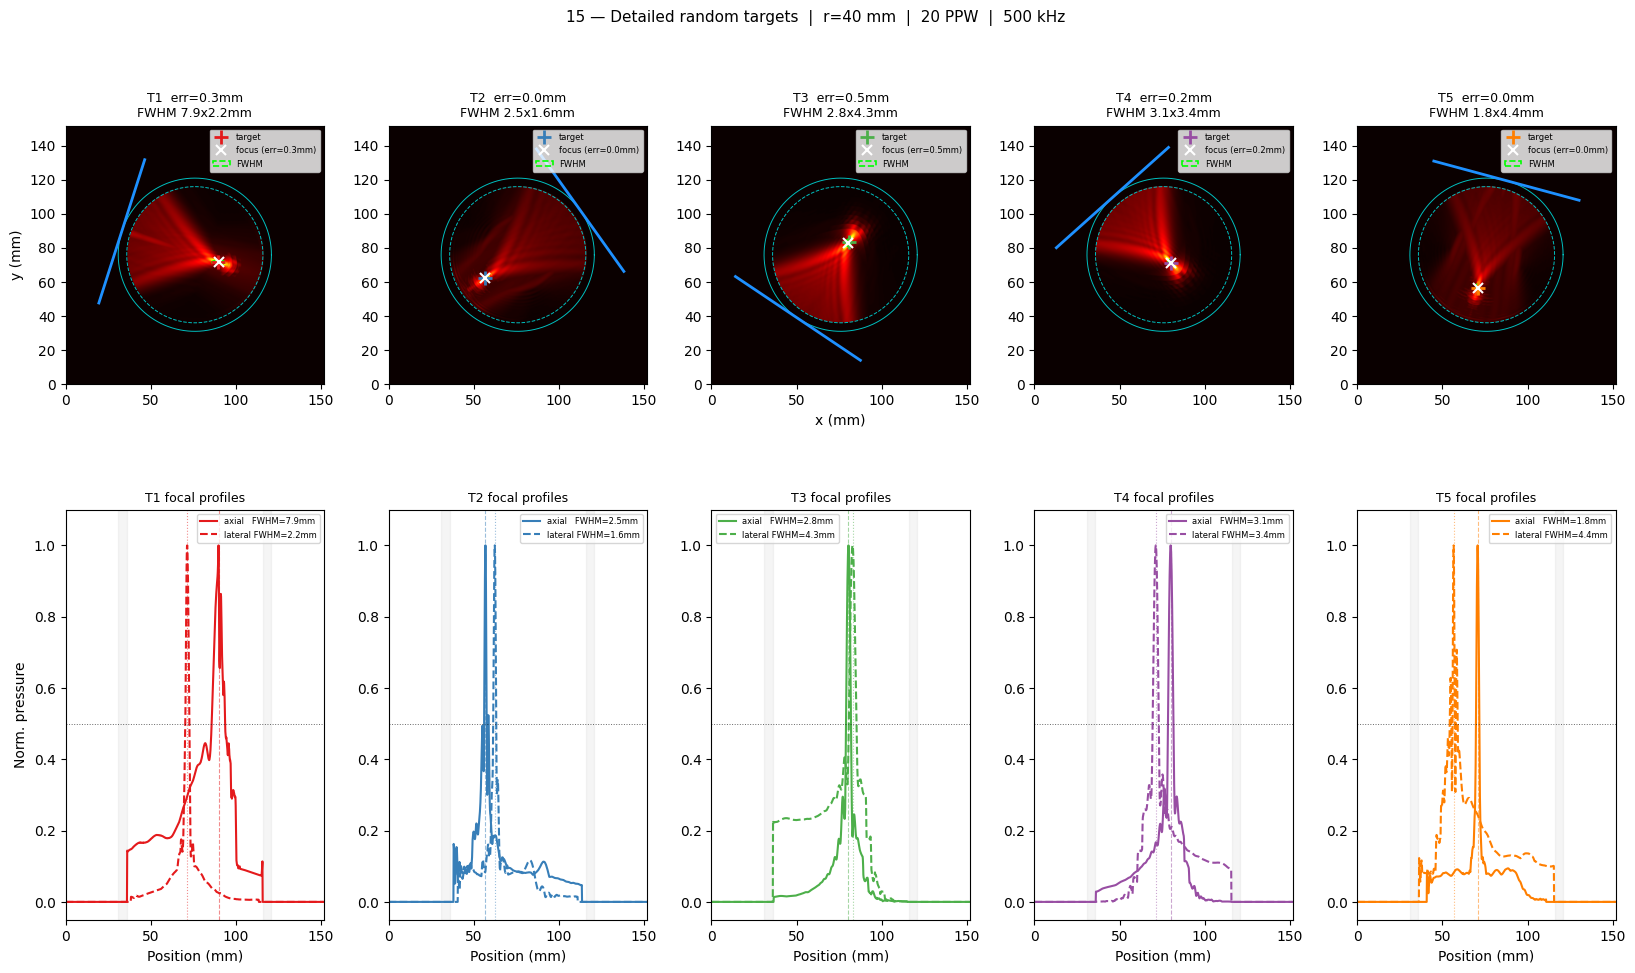


=== DETAILED SUMMARY ===
  T   r(mm)   angle   err(mm)   FWHM_ax   FWHM_lat   peak_P(Pa)
  1    14.4    342d       0.3       7.9        2.2    3.645e-02
  2    23.3    216d       0.0       2.5        1.6    4.427e-02
  3     8.9     56d       0.5       2.8        4.3    3.454e-02
  4     6.5    312d       0.2       3.1        3.4    3.554e-02
  5    20.0    255d       0.0       1.8        4.4    5.071e-02

GIFs saved: 15_t1_focus.gif  15_t2_focus.gif  15_t3_focus.gif  15_t4_focus.gif  15_t5_focus.gif


In [13]:
# Self-contained.  Same targets as cell 14 (seed=42).
# Progress bars on science sims; quiet animation sims to reduce noise.
# Saves 15_t{N}_focus.gif for each target.

from matplotlib.animation import FuncAnimation, PillowWriter

# -- Medium setup (same as cells 10-14) ---------------------------------------
c_water  = 1482.0;  rho_water = 1000.0
c_skull  = 2900.0;  rho_skull = 1900.0
c_brain  = 1560.0;  rho_brain = 1040.0
freq     = 500e3
dx       = (c_water / freq) / 20
Nx, Ny   = 1024, 1024
cx, cy   = Nx // 2, Ny // 2
BRAIN_R  = 40.0;  SKULL_T = 5.0
s_in15   = BRAIN_R            * 1e-3 / dx
s_out15  = (BRAIN_R + SKULL_T)* 1e-3 / dx
cx_mm15  = cx * dx * 1e3;  cy_mm15 = cy * dx * 1e3

XX15, YY15 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R15       = np.sqrt((XX15 - cx)**2 + (YY15 - cy)**2)
skull_m15 = (R15 >= s_in15) & (R15 < s_out15)
brain_m15 =  R15 <  s_in15

ss15  = np.full((Nx, Ny), c_water,  dtype=float)
rho15 = np.full((Nx, Ny), rho_water, dtype=float)
ss15[skull_m15] = c_skull;  rho15[skull_m15] = rho_skull
ss15[brain_m15] = c_brain;  rho15[brain_m15] = rho_brain

kg15  = kWaveGrid([Nx, Ny], [dx, dx])
kg15.makeTime(c_skull, cfl=0.3)
med15 = kWaveMedium(sound_speed=ss15, density=rho15)
print(f"Nt={kg15.Nt}  dt={kg15.dt:.2e} s  dx={dx*1e3:.3f} mm (20 PPW)")

# Animation sensor (every 4th grid point)
STRIDE15   = 8
anim_Nx15  = Nx // STRIDE15
anim_Ny15  = Ny // STRIDE15
anim_mask15 = np.zeros((Nx, Ny), dtype=float)
anim_mask15[::STRIDE15, ::STRIDE15] = 1
anim_dt15    = max(1, kg15.Nt // 150)
t_frame_us15 = np.arange(0, kg15.Nt, anim_dt15) * kg15.dt * 1e6


# -- Helpers ------------------------------------------------------------------
def build_tx15(face_angle_rad, ap_mm=90.0, sd_mm=0.0):
    sd_px  = max(1, int(sd_mm * 1e-3 / dx))
    h_ap   = int((ap_mm / 2) * 1e-3 / dx)
    r_tx   = int(s_out15) + sd_px
    tx_ang = face_angle_rad + np.pi
    tc_x   = cx + r_tx * np.cos(tx_ang)
    tc_y   = cy + r_tx * np.sin(tx_ang)
    perp_x = -np.sin(tx_ang);  perp_y = np.cos(tx_ang)
    mask   = np.zeros((Nx, Ny))
    for k in range(-h_ap, h_ap + 1):
        xi = int(round(tc_x + k * perp_x))
        yi = int(round(tc_y + k * perp_y))
        if 20 <= xi < Nx - 20 and 20 <= yi < Ny - 20:
            mask[xi, yi] = 1
    return mask


def fwhm_mm(profile):
    half_max = np.max(profile) / 2.0
    if half_max == 0:
        return 0.0
    above = np.where(profile >= half_max)[0]
    return (above[-1] - above[0]) * dx * 1e3 if len(above) > 1 else 0.0


def run_tr15_detailed(tgt_x_px, tgt_y_px, face_angle_rad, label):
    """Run 4 sims: forward science + anim, backward science + anim.
    Returns result dict with p_max, FWHM, GIF frames, etc.
    """
    emask = build_tx15(face_angle_rad)
    burst = tone_burst(1 / kg15.dt, freq, 5).flatten()

    # -- Forward science (progress bar shown) ---------------------------------
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(tgt_x_px), int(tgt_y_px)] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    print(f"  [{label}] Forward  →")
    p_fwd = kspaceFirstOrder(kg15, med15, src_f, sen_f,
                              device='gpu', dtype='float32')['p']

    # -- Forward animation (quiet) --------------------------------------------
    sen_fa = kSensor();  sen_fa.mask = anim_mask15.copy();  sen_fa.record = ['p']
    data_fa = kspaceFirstOrder(kg15, med15, src_f, sen_fa,
                                device='gpu', dtype='float32', quiet=True)
    fwd_frames = (data_fa['p'][:, ::anim_dt15]
                  .reshape(anim_Nx15, anim_Ny15, len(t_frame_us15)))

    # -- Backward science (progress bar shown) --------------------------------
    import cupy; cupy.get_default_memory_pool().free_all_blocks()  # release pool cache from prior sims
    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_fwd[:, ::-1]
    sen_b = kSensor();  sen_b.mask = brain_m15.astype(float);  sen_b.record = ['p_max']
    print(f"  [{label}] Backward ←")
    p_max_sparse = kspaceFirstOrder(kg15, med15, src_b, sen_b,
                                    device='gpu', dtype='float32')['p_max']
    p_max = np.zeros((Nx, Ny))
    p_max[brain_m15] = p_max_sparse

    # -- Backward animation (quiet) -------------------------------------------
    sen_ba = kSensor();  sen_ba.mask = anim_mask15.copy();  sen_ba.record = ['p']
    data_ba = kspaceFirstOrder(kg15, med15, src_b, sen_ba,
                                device='gpu', dtype='float32', quiet=True)
    bwd_frames = (data_ba['p'][:, ::anim_dt15]
                  .reshape(anim_Nx15, anim_Ny15, len(t_frame_us15)))

    # -- Analysis -------------------------------------------------------------
    p_br = p_max.copy();  p_br[~brain_m15] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    tg_x = tgt_x_px * dx * 1e3;  tg_y = tgt_y_px * dx * 1e3
    err  = np.sqrt((pk_x - tg_x)**2 + (pk_y - tg_y)**2)

    prof_axial   = p_br[:, pj]
    prof_lateral = p_br[pi, :]
    fw_ax  = fwhm_mm(prof_axial)
    fw_lat = fwhm_mm(prof_lateral)
    peak_P = np.max(p_br)

    print(f"  [{label}] err={err:.1f} mm  FWHM axial={fw_ax:.1f} mm  lateral={fw_lat:.1f} mm  peak={peak_P:.3e} Pa")

    return {
        'p_max': p_max, 'p_br': p_br,
        'tg_x': tg_x, 'tg_y': tg_y,
        'pk_x': pk_x, 'pk_y': pk_y,
        'err': err, 'fw_ax': fw_ax, 'fw_lat': fw_lat, 'peak_P': peak_P,
        'prof_axial': prof_axial, 'prof_lateral': prof_lateral,
        'pi': pi, 'pj': pj,
        'fwd_frames': fwd_frames, 'bwd_frames': bwd_frames,
        'emask': emask
    }


def save_combined_gif15(res, label, filename):
    """Save combined forward+backward GIF (forward → pause → backward)."""
    n_pause = 8
    fwd = res['fwd_frames']
    bwd = res['bwd_frames']
    pause = np.repeat(fwd[:, :, -1:], n_pause, axis=2)
    all_f = np.concatenate([fwd, pause, bwd], axis=2)
    n_fwd_end = fwd.shape[2] + n_pause

    vmax = np.percentile(np.abs(all_f), 99.5)
    if vmax == 0: vmax = 1.0
    extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
    theta  = np.linspace(0, 2*np.pi, 360)
    r_in   = s_in15  * dx * 1e3
    r_out  = s_out15 * dx * 1e3

    fig, ax = plt.subplots(figsize=(5, 5), tight_layout=True)
    im = ax.imshow(all_f[:, :, 0].T, origin='lower', extent=extent,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    plt.colorbar(im, ax=ax, label='Pressure (Pa)', shrink=0.85)
    ax.plot(cx_mm15 + r_in*np.cos(theta),  cy_mm15 + r_in*np.sin(theta),  'k--', lw=0.7, alpha=0.4)
    ax.plot(cx_mm15 + r_out*np.cos(theta), cy_mm15 + r_out*np.sin(theta), 'k-',  lw=0.7, alpha=0.4)
    ax.plot(res['tg_x'], res['tg_y'], 'g+', ms=10, mew=2)

    # Transducer bar overlay
    fa = np.arctan2(res['tg_y'] - cy_mm15, res['tg_x'] - cx_mm15)
    tx_ang = fa + np.pi
    r_tx = (int(s_out15) + 1) * dx * 1e3
    tc_x = cx_mm15 + r_tx * np.cos(tx_ang)
    tc_y = cy_mm15 + r_tx * np.sin(tx_ang)
    perp_x_mm = -np.sin(tx_ang) * 45.0
    perp_y_mm =  np.cos(tx_ang) * 45.0
    ax.plot([tc_x - perp_x_mm, tc_x + perp_x_mm],
            [tc_y - perp_y_mm, tc_y + perp_y_mm],
            'dodgerblue', lw=2.5, solid_capstyle='butt')

    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    title_obj = ax.set_title(f'{label} — FORWARD  t={t_frame_us15[0]:.1f} us')

    def update(fi):
        im.set_data(all_f[:, :, fi].T)
        if fi < fwd.shape[2]:
            t_us = t_frame_us15[fi]
            title_obj.set_text(f'{label} — FORWARD  t={t_us:.1f} us')
        elif fi < n_fwd_end:
            title_obj.set_text(f'{label} — PAUSE')
        else:
            bfi = fi - n_fwd_end
            t_us = t_frame_us15[bfi]
            title_obj.set_text(f'{label} — BACKWARD  t={t_us:.1f} us')
        return [im, title_obj]

    anim = FuncAnimation(fig, update, frames=all_f.shape[2], interval=35, blit=True)
    anim.save(filename, writer=PillowWriter(fps=25), dpi=100)
    plt.close()
    print(f"  Saved {filename}")


# -- Generate targets (same seed=42 as cell 14) -------------------------------
np.random.seed(42)
targets15 = []
while len(targets15) < 5:
    r_mm  = np.random.uniform(5, BRAIN_R - 10)
    angle = np.random.uniform(0, 2 * np.pi)
    tx_mm = cx_mm15 + r_mm * np.cos(angle)
    ty_mm = cy_mm15 + r_mm * np.sin(angle)
    tx_px = int(round(tx_mm / (dx * 1e3)))
    ty_px = int(round(ty_mm / (dx * 1e3)))
    if brain_m15[tx_px, ty_px]:
        targets15.append({'x_mm': tx_mm, 'y_mm': ty_mm, 'x_px': tx_px,
                          'y_px': ty_px, 'face_angle': angle, 'r_mm': r_mm})


# -- Run detailed TR for each target ------------------------------------------
results15 = []
for i, tgt in enumerate(targets15):
    lbl = f'T{i+1} ({tgt["x_mm"]:.0f},{tgt["y_mm"]:.0f})mm'
    print(f"\n=== Target {i+1}: ({tgt['x_mm']:.1f}, {tgt['y_mm']:.1f}) mm  "
          f"r={tgt['r_mm']:.1f} mm  angle={np.degrees(tgt['face_angle']):.0f} deg ===")
    res = run_tr15_detailed(tgt['x_px'], tgt['y_px'], tgt['face_angle'], lbl)
    results15.append(res)
    save_combined_gif15(res, lbl, f'15_t{i+1}_focus.gif')


# -- Summary figure -----------------------------------------------------------
theta15  = np.linspace(0, 2*np.pi, 360)
r_in15   = s_in15  * dx * 1e3
r_out15  = s_out15 * dx * 1e3
extent15 = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
colors5  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig = plt.figure(figsize=(20, 10))
gs_top = fig.add_gridspec(1, 5, top=0.93, bottom=0.54, wspace=0.25)
gs_bot = fig.add_gridspec(1, 5, top=0.48, bottom=0.07, wspace=0.25)

for i, (res, tgt) in enumerate(zip(results15, targets15)):
    col = colors5[i]

    # -- Focus map (top row) --------------------------------------------------
    ax_top = fig.add_subplot(gs_top[0, i])
    im = ax_top.imshow(res['p_br'].T, origin='lower', extent=extent15, cmap='hot')
    ax_top.plot(cx_mm15 + r_in15*np.cos(theta15),  cy_mm15 + r_in15*np.sin(theta15),  'c--', lw=0.7)
    ax_top.plot(cx_mm15 + r_out15*np.cos(theta15), cy_mm15 + r_out15*np.sin(theta15), 'c-',  lw=0.7)
    ax_top.plot(res['tg_x'], res['tg_y'], '+', color=col, ms=10, mew=2, label='target')
    ax_top.plot(res['pk_x'], res['pk_y'], 'wx', ms=7,  mew=1.5,
                label=f'focus (err={res["err"]:.1f}mm)')

    # FWHM ellipse at focus
    from matplotlib.patches import Ellipse
    ell = Ellipse((res['pk_x'], res['pk_y']),
                  width=res['fw_ax'], height=res['fw_lat'],
                  edgecolor='lime', facecolor='none', lw=1.2, linestyle='--', label='FWHM')
    ax_top.add_patch(ell)

    # Transducer bar
    fa   = tgt['face_angle']
    tx_a = fa + np.pi
    r_tx_mm = (int(s_out15) + 1) * dx * 1e3
    tc_x = cx_mm15 + r_tx_mm * np.cos(tx_a)
    tc_y = cy_mm15 + r_tx_mm * np.sin(tx_a)
    ax_top.plot([tc_x + 45*(-np.sin(tx_a)), tc_x - 45*(-np.sin(tx_a))],
                [tc_y + 45*np.cos(tx_a),    tc_y - 45*np.cos(tx_a)],
                color='dodgerblue', lw=2, solid_capstyle='butt')

    ax_top.set_xlabel('x (mm)' if i == 2 else '')
    ax_top.set_ylabel('y (mm)' if i == 0 else '')
    ax_top.set_title(f'T{i+1}  err={res["err"]:.1f}mm\n'
                     f'FWHM {res["fw_ax"]:.1f}x{res["fw_lat"]:.1f}mm', fontsize=9)
    ax_top.legend(fontsize=6, loc='upper right')

    # -- Focal profiles (bottom row) ------------------------------------------
    ax_bot = fig.add_subplot(gs_bot[0, i])
    x_ax = np.arange(Nx) * dx * 1e3
    y_ax = np.arange(Ny) * dx * 1e3

    # Normalize profiles to peak
    ax_prof = res['prof_axial'] / (np.max(res['prof_axial']) + 1e-30)
    lat_prof = res['prof_lateral'] / (np.max(res['prof_lateral']) + 1e-30)

    ax_bot.plot(x_ax, ax_prof,  color=col,     lw=1.5, label=f'axial   FWHM={res["fw_ax"]:.1f}mm')
    ax_bot.plot(y_ax, lat_prof, color=col, lw=1.5, linestyle='--',
                label=f'lateral FWHM={res["fw_lat"]:.1f}mm')
    ax_bot.axhline(0.5, color='k', lw=0.7, ls=':', alpha=0.6)
    ax_bot.axvline(x=res['pk_x'], color=col,   lw=0.8, ls='--', alpha=0.5)
    ax_bot.axvline(x=res['pk_y'], color=col, lw=0.8, ls=':',  alpha=0.5)

    # Skull shading (x-direction)
    ax_bot.axvspan(cx_mm15 - r_out15, cx_mm15 - r_in15, alpha=0.08, color='gray')
    ax_bot.axvspan(cx_mm15 + r_in15,  cx_mm15 + r_out15, alpha=0.08, color='gray')

    ax_bot.set_xlim(0, Nx*dx*1e3)
    ax_bot.set_ylim(-0.05, 1.1)
    ax_bot.set_xlabel('Position (mm)')
    ax_bot.set_ylabel('Norm. pressure' if i == 0 else '')
    ax_bot.set_title(f'T{i+1} focal profiles', fontsize=9)
    ax_bot.legend(fontsize=6)

plt.suptitle('15 — Detailed random targets  |  r=40 mm  |  20 PPW  |  500 kHz',
             fontsize=11, y=0.98)
plt.savefig('15_detailed_targets.png', dpi=150, bbox_inches='tight')
plt.show()


# -- Final summary table ------------------------------------------------------
print("\n=== DETAILED SUMMARY ===")
print(f"{'T':>3}  {'r(mm)':>6}  {'angle':>6}  {'err(mm)':>8}  {'FWHM_ax':>8}  {'FWHM_lat':>9}  {'peak_P(Pa)':>11}")
for i, (res, tgt) in enumerate(zip(results15, targets15)):
    print(f"  {i+1:1d}  {tgt['r_mm']:6.1f}  {np.degrees(tgt['face_angle']):5.0f}d  "
          f"{res['err']:8.1f}  {res['fw_ax']:8.1f}  {res['fw_lat']:9.1f}  {res['peak_P']:11.3e}")
print(f"\nGIFs saved: " + "  ".join([f'15_t{i+1}_focus.gif' for i in range(5)]))


# Monkey Skull Sims

### 16_monkey_skull_mask

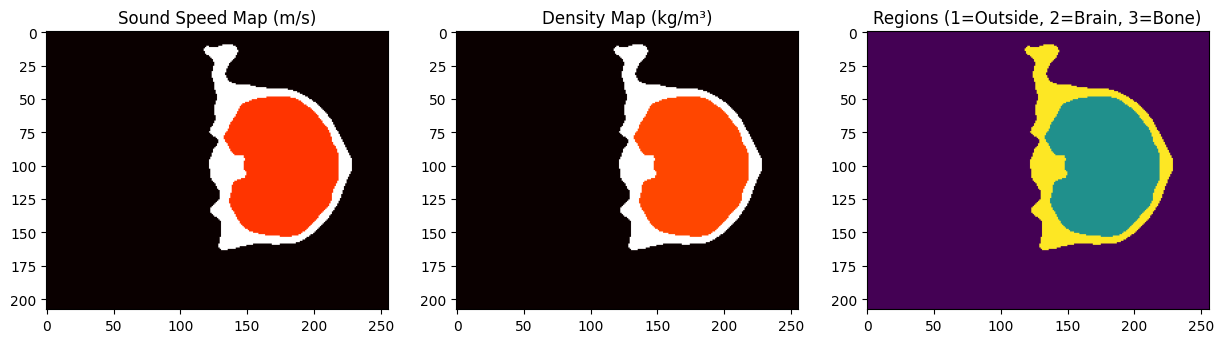

In [ ]:
# ==========================================
# CELL 16: GENERATE BRAIN AND EXTERNAL MASKS
# ==========================================

# 1. Load the 2D bone mask you saved from the interactive tool
# Change this path if your working directory is different
data_dir = Path(r"C:\Users\bengi\Documents\Pesaran Lab")
bone_mask = np.load(data_dir / "bone_mask_2d.npy").astype(bool)

# 2. Delineate the regions
# Fill the bone ring to get the entire head (bone + brain)
head_mask = binary_fill_holes(bone_mask)

# Brain is inside the head, but isn't bone
brain_mask = head_mask & ~bone_mask

# Outside (Air/Water) is everything not in the head mask
outside_mask = ~head_mask

# 3. Define Acoustic Properties (c: m/s, rho: kg/m³, alpha: Np/MHz/m)
props = {
    'bone':  {'c': 3100.0, 'rho': 2200.0, 'alpha': 21.5},
    'brain': {'c': 1560.0, 'rho': 1040.0, 'alpha': 6.9},   # Standard soft tissue
    'air':   {'c': 343.0,  'rho': 1.2,    'alpha': 0.0},   # Warning: highly reflective, requires small dt
    'water': {'c': 1482.0, 'rho': 1000.0, 'alpha': 3.48e-4} 
}

# Toggle this depending on whether you want air or water outside!
OUTSIDE_ENV = 'air' 

# 4. Build the comprehensive maps
c_map     = np.zeros_like(bone_mask, dtype=np.float32)
rho_map   = np.zeros_like(bone_mask, dtype=np.float32)
alpha_map = np.zeros_like(bone_mask, dtype=np.float32)

# Apply Outside
c_map[outside_mask]     = props[OUTSIDE_ENV]['c']
rho_map[outside_mask]   = props[OUTSIDE_ENV]['rho']
alpha_map[outside_mask] = props[OUTSIDE_ENV]['alpha']

# Apply Brain
c_map[brain_mask]     = props['brain']['c']
rho_map[brain_mask]   = props['brain']['rho']
alpha_map[brain_mask] = props['brain']['alpha']

# Apply Bone
c_map[bone_mask]     = props['bone']['c']
rho_map[bone_mask]   = props['bone']['rho']
alpha_map[bone_mask] = props['bone']['alpha']

# 5. Save the full maps for k-Wave
np.save(data_dir / "c_map_full.npy", c_map)
np.save(data_dir / "rho_map_full.npy", rho_map)
np.save(data_dir / "alpha_map_full.npy", alpha_map)

# 6. Quick visualization to verify
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(c_map, cmap='hot')
ax[0].set_title('Sound Speed Map (m/s)')
ax[1].imshow(rho_map, cmap='hot')
ax[1].set_title('Density Map (kg/m³)')

# Combine masks into a color-coded image for easy viewing
display_mask = np.zeros(bone_mask.shape)
display_mask[outside_mask] = 1 # Air = 1
display_mask[brain_mask] = 2   # Brain = 2
display_mask[bone_mask] = 3    # Bone = 3

ax[2].imshow(display_mask, cmap='viridis')
ax[2].set_title('Regions (1=Outside, 2=Brain, 3=Bone)')
plt.show()

### 17_monkey_skull_sim

Running simulation...


k-Wave: 100%|██████████| 9938/9938 [00:07<00:00, 1322.22step/s]


Done — max pressure: 56.1 kPa


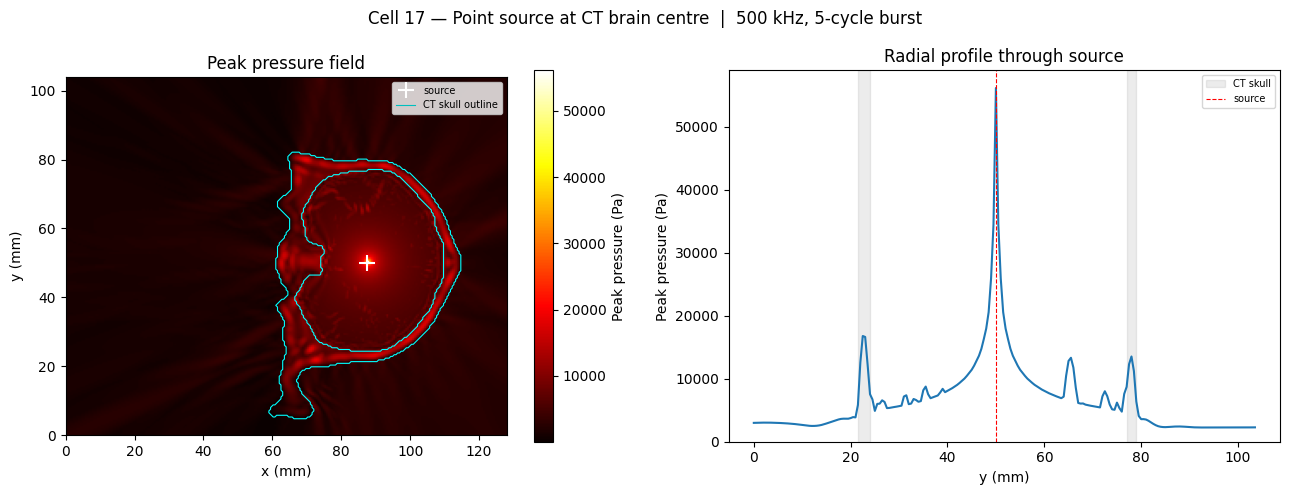

In [30]:
# ── CRITICAL FIX: Prevent k-Wave NaN Explosion ────────────────────────────────
# If there is air in the medium, the 1800x density contrast will crash the sim.
# We clamp any low values back to water-like properties right before running.
medium.density[medium.density < 1000] = 1000.0
medium.sound_speed[medium.sound_speed < 1000] = 1482.0

# ── Source: single point at brain centre ──────────────────────────────────────
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[cx, cy] = 1
source.p = burst * 1e5   # 100 kPa

# ── Sensor: full field, record peak pressure ──────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)

# Safety check so the plot doesn't crash if it ever fails again
if np.isnan(p_max).any():
    print("WARNING: Sim hit NaNs. Converting to 0 so plot still renders.")
    p_max = np.nan_to_num(p_max)

print(f"Done — max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
cx_mm  = cx * dx * 1e3
cy_mm  = cy * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D peak-pressure field
ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')

# Draw the real CT skull boundaries
ax.contour(bone_mask.T, levels=[0.5], extent=extent, colors='cyan', linewidths=0.8)

ax.plot(cx_mm, cy_mm, 'w+', ms=12, mew=1.5, label='source')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.plot([], [], 'c-', lw=0.8, label='CT skull outline') # Dummy line for legend
ax.legend(fontsize=7, loc='upper right')

# Right: radial profile through centre
ax = axes[1]
radial = p_max[cx, :]                  # slice along y through source
y_mm   = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, radial)

# Shade the skull regions exactly where the bone_mask is True along this slice
skull_1d = bone_mask[cx, :]
# Using max value to set the shading height safely
y_max = np.max(radial) if np.max(radial) > 0 else 1.0 
ax.fill_between(y_mm, 0, y_max*1.05, where=skull_1d, color='gray', alpha=0.15, label='CT skull')

ax.axvline(x=cy_mm, color='red', lw=0.8, linestyle='--', label='source')
ax.set_xlabel('y (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Radial profile through source')
ax.legend(fontsize=7)
ax.set_ylim(0, y_max*1.05)

plt.suptitle('Cell 17 — Point source at CT brain centre  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('17_centre_source.png', dpi=150)
plt.show()